# Ocean Visions Research Update — the figures

One notebook that draws every figure in the 28 September 2026 Ocean Visions
talk on how ERA5 represents liquid-containing cloud at Utqiaġvik (Barrow).
Nothing is computed here. Every figure is a call into the analysis module
that its working notebook drives, on data loaded by that module's own
`prepare()`, so this notebook and the working notebooks cannot drift apart.

| # | figure | module call | working notebook (section) |
|---|---|---|---|
| 1 | ERA5 seasonal hours against one observed number | `lwph.fig_era5_vs_obs_simple_forOV` (slide copy of `fig_era5_vs_obs_simple`) + `print_era5_vs_obs_mean_pct_diff` | `comparison_with_Genie_Obs` (5) |
| 2 | Monthly box-and-whisker, liquid containing, ERA5 vs ARM | `lwph.fig_monthly_box_era5_vs_obs_build_forOV` (slide copy of `fig_monthly_box_era5_vs_obs_build`) | `comparison_with_Genie_Obs` (7b) |
| 3 | Liquid retention by quality knob, ERA5 vs ARM | `lwph.fig_liquid_retention_by_knob` | `plot_lwp_threshold_sweep` (8) |
| 4 | Cloud duration and in-cloud wind speed at the ARM cell, two bottom x axes | `clw.fig_cloudDuration_andWind_forOV` + `cse.print_site_liquid_hours_per_day` | `cloud_spatial_extent` (2, 6) |
| 4-alt | Distribution of the Taylor horizontal extent (the previous figure 4) | `cse.fig_taylor_hist` | `cloud_spatial_extent` (2) |
| 5 | How often, and how much liquid — maps side by side | `mlh.fig_fraction_and_lwp` | `map_liquid_containing_hours` (5b) |
| 6 | One season month by month, with the ice edge | `mlh.fig_season_monthly_maps` | `map_liquid_containing_hours` (5c) |
| 7a | Downwelling longwave by sky state — liquid containing, ice only, clear — monthly boxes at the ARM cell | `dlr.fig_monthly_dlr_box` + `dlr.print_monthly_dlr_table` | new (`plot_dlr_by_phase.py`) |
| 7b | The same over every cell of the Barrow domain, split by surface class, and the share of hours in each state; slide versions (`*_forOV`) of both | `dlr.fig_monthly_dlr_box_domain`, `dlr.fig_monthly_dlr_box_by_class` (+ `_forOV`) + `dlr.print_state_fraction_table` | new (`plot_dlr_by_phase.py`) |
| 7c | Distribution of hourly downwelling longwave — ARM cell against the whole domain | `dlr.fig_dlr_pdf` | new (`plot_dlr_by_phase.py`) |
| 8 | Normalised surface-flux response to DLR + SW$_{net}$ | `tfr.fig_monthly_response_simple_normalized` | `turbulent_flux_response_to_DLR_and_SW` (4a) |
| — | Domain thumbnail: the Arctic with the Barrow domain outlined, for the corner of domain-wide figures | `mlh.fig_domain_thumbnail` | new (`map_liquid_hours.py`) |

The modules live in `ERA5/surface_energy_budget/`; the setup cell puts that
directory on `sys.path`. ERA5 is read from the `data/` directory beside the
modules (`storage="local"`) and the ARM observation tables from the same
folder, so nothing is copied here.

## Settings

Each run reproduces its working notebook's `prepare()` call **as it stands
today**. Two settings therefore differ between figures. They are named
constants in the settings cell rather than buried in the calls, so the
difference is visible and can be removed in one place if the talk should be
internally consistent:

- `ice_fraction_min` — the IWP/CWP share at or above which a scene is
  **ice only** (everything water-bearing below it is *liquid containing*).
  **0.90** for figures 1–2 and 7 (the ARM-cell figures, following
  `comparison_with_Genie_Obs.ipynb`, changed from 0.85 on 2026-09-17);
  **0.85** for figures 3–6 and 8, whose notebooks still use the older value.
- `min_lwp` — the liquid water path below which liquid counts as absent.
  **0.01 g m⁻²** everywhere except figure 8, whose notebook uses
  **2.0 g m⁻²**. Figure 8 also runs one more season (2014/15–2025/26).

## Cost

Eight streaming passes over the archive — three single-cell runs, one
domain-wide mask, a second two-season mask for the cloud-level wind, two map
runs, one flux-response run — each several minutes, plus two cheap passes for
figure 7: the per-hour extraction at the ARM cell (~25 s) and the domain-wide
flux histograms (~30 s). Load once (the *Load the data* section), then redraw any figure for
free. The whole set is held in memory at once; expect a few GB.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt


def repo_root(start: Path) -> Path:
    """Walk up from ``start`` to the directory holding ``.git``."""
    for p in (start, *start.parents):
        if (p / ".git").exists():
            return p
    raise FileNotFoundError(f"no .git directory above {start}")


# The analysis modules and their data live in ERA5/surface_energy_budget.
# Anchoring on the repository root rather than on this notebook's working
# directory keeps the imports working however Jupyter was launched.
REPO_ROOT = repo_root(Path.cwd().resolve())
SEB_DIR = REPO_ROOT / "ERA5" / "surface_energy_budget"
assert SEB_DIR.is_dir(), f"analysis modules not found at {SEB_DIR}"
if str(SEB_DIR) not in sys.path:
    sys.path.insert(0, str(SEB_DIR))

import plot_lwp_histogram_by_surface_class as lwph   # figures 1-3, 7
import cloud_spatial_extent as cse                   # figure 4
import cloud_level_wind as clw                       # figure 4, cloud-level wind
import map_liquid_hours as mlh                       # figures 5-6
import plot_dlr_by_phase as dlr                      # figure 7
import turbulent_flux_response as tfr                # figure 8

# open_mfdataset warns about join/compat defaults changing; the modules pin
# both explicitly, so the warning is noise here.
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams["figure.dpi"] = 110      # on-screen only; saved files use DPI

# PNGs are written beside this notebook. Set to None to display only.
SAVE_DIR = REPO_ROOT / "Presentations_and_papers" / "Ocean_Visions" / "figures"
DPI = 350                             # saved-file resolution, every figure

## Shared settings

The Barrow region, the eleven October–March cold seasons matching Genie's
2014/15–2024/25 record, the fractional phase scheme and the overcast gate —
copied from the load cell of `comparison_with_Genie_Obs.ipynb`. The
precipitation filter is the one from section 4 of that notebook: ERA5's
`tp` is the rate the published 0.1 mm hr⁻¹ convention is defined on, and an
hour is kept when `tp < 0.05 mm hr⁻¹`. Genie's ver2 seasonal categories are
non-precipitating, so the filtered run is the like-for-like pairing for
figure 1; her monthly spreadsheet includes precipitating cases, so figure 2
uses the unfiltered run.

In [2]:
# Shared by every run below. Any departure from these is made explicitly in
# the load cell that needs it, so the differences between figures are visible.
COMMON = dict(
    region="barrow",
    years=tuple(range(2014, 2025)),   # season START years: 2014/15 .. 2024/25
    season_start=(10, 1),
    season_end=(3, 31),

    phase_mode="fraction",
    liquid_fraction_min=0.90,         # LWP/CWP at or above this = liquid only

    min_lwp=0.01,                     # g m-2, liquid below this counts as absent
    min_iwp=0.01,                     # g m-2, ice below this counts as absent

    min_cloud_fraction=0.95,          # overcast only: tcc >= 0.95
    lsm_tol=0.01,                     # land-sea mask tolerance (module default)
    storage="local",                  # data/ beside the modules
    dpi=DPI,
)

# The precipitation filter from comparison_with_Genie_Obs.ipynb, section 4.
PRECIP = dict(no_precip=True,
              precip_var="rate",      # tp, the quantity the 0.1 mm/hr convention uses
              precip_rate_max=0.05)   # mm hr-1; an hour at or above this is dropped

# IWP/CWP at or above this = ice only. The two working-notebook values -- see
# the header. Set both to one number for an internally consistent talk.
ICE_FRACTION_MIN_COMPARISON = 0.90    # figures 1-2, 7: the ARM-cell figures
ICE_FRACTION_MIN_DOMAIN = 0.85        # figures 3-6, 8: the other four notebooks

## Load the data

Seven passes, grouped by module. Each is the `prepare()` call of the working
notebook named in the comment, with the shared settings above substituted
for the values it spells out.

### Single-cell runs — figures 1, 2 and 3

`lwph.prepare` streams the archive once, classifies every cell-hour by
surface and phase, and keeps the per-season and per-month hour counts the
comparison figures read. The ARM cell is resolved inside the module
(`surface_class="arm_site"`).

In [13]:
# Figure 1: precipitation filtered -- `A_precip` in comparison_with_Genie_Obs.
A_precip = lwph.prepare(**COMMON, **PRECIP,
                        ice_fraction_min=ICE_FRACTION_MIN_COMPARISON)

removed = A_precip.col["precip_removed"]
before = A_precip.col["cloudy_before_precip"]
print(f"\nprecip filter removed {100 * removed / before:.1f}% of cloudy cell-hours")

Liquid-bearing cloud hours by LWP and surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : cloud liquid water (tclw)
  Cell weight: area (cos latitude)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.9 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.9
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    201

In [14]:
# Figure 2: all sky -- `A` in comparison_with_Genie_Obs. Genie's monthly
# spreadsheet includes precipitating cases, so nothing is filtered here.
A_allsky = lwph.prepare(**COMMON, ice_fraction_min=ICE_FRACTION_MIN_COMPARISON)

Liquid-bearing cloud hours by LWP and surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : cloud liquid water (tclw)
  Cell weight: area (cos latitude)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.9 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.9
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    201

In [ ]:
# Figure 3: all sky, with the min_lwp sweep classified inside the same pass --
# `A` in plot_lwp_threshold_sweep.ipynb. Only the liquid floor moves; min_iwp
# is held fixed, so any change along the curve is the liquid threshold alone.
A_sweep = lwph.prepare(
    **COMMON,
    ice_fraction_min=ICE_FRACTION_MIN_COMPARISON,

    sweep_lwp_min=0.1,                # g m-2, low end of the x axis
    sweep_lwp_max=20.0,               # g m-2, high end
    sweep_points=21,                  # all classified in one pass
    sweep_spacing="linear",           # "log" resolves the sub-1 g m-2 region

    show_ice_only=False,              # ice-only rises when liquid gets zeroed
                                      # out of mixed-phase, not when ice grows;
                                      # off so it isn't misread
)

Liquid-bearing cloud hours by LWP and surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : cloud liquid water (tclw)
  Cell weight: area (cos latitude)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.85
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2

### Per-hour table at the ARM cell — figure 7a

`fit_cloud_thresholds.extract_site_series` reduces `A_precip` to one row per
hour at the ARM grid cell — season, month, `tcc`, the floored water paths,
the ice share, the rain flag — here with the downwelling longwave flux
(`msdwlwrf`) carried along. It is the table behind section 7b's LWP and
duration figures in the working notebook, so figure 7's liquid-containing
hours are those figures' hours exactly; `verify_against_fit` asserts it.
About half a minute.

In [6]:
S_precip = dlr.extract_site_table(A_precip)     # per hour at the ARM cell, with msdwlwrf
dlr.verify_against_fit(S_precip, A_precip)

  verified: 16,439 liquid-containing hours match fit_cloud_thresholds hour for hour


### Domain-wide flux histograms — figures 7b and 7c

Every cell of the domain, every hour: ~120 million cell-hours, too many to
hold, so `prepare_domain` streams the archive once and accumulates histograms
of `msdwlwrf` at 1 W m⁻² per month, sky state and precipitation filter (both
the filtered and the unfiltered populations are kept). Cell-hours are
cos(latitude)-weighted, so a share of hours reads as a share of the domain's
area-time. The ARM cell's histograms ride along in the same pass, and
reproduce the per-hour table's counts exactly. The same pass also keeps the
histograms per surface class (7b by class), per season, per day, and of
the cloud radiative effect DLR − DLR$_{\mathrm{clear}}$ from ERA5's clear-sky
flux, for the difference methods of the ver2 figure. About half a minute.

In [7]:
D_precip = dlr.prepare_domain(A_precip)     # histograms per month x sky state x filter

  Domain DLR pass: 41 x 61 cells, 48,120 hours, bins of 1 W m-2
  done: 48,120 hours x 2,501 cells; 120,348,120 valid cell-hours, 107,015,034 after the precipitation filter; 0 cell-hours unclassified by surface


### Domain-wide hourly mask and 10 m wind — figure 4

One pass keeps the hourly liquid-containing mask and the 10 m wind at every
cell — about 1.1 GB for eleven seasons — so that run lengths can be found at
every cell without re-reading the archive. Settings are those of `A_precip`
with the domain value of `ice_fraction_min`, exactly as
`cloud_spatial_extent.ipynb` loads them.

In [ ]:
E = cse.prepare_extent(**COMMON, **PRECIP,
                       ice_fraction_min=ICE_FRACTION_MIN_COMPARISON)

# One sample per event: a maximal run of consecutive liquid-containing hours
# at one cell, with L = mean |U10| x run length. exclude_months is left
# empty -- the ARM instrument outages in GENIE_EXCLUDED_MONTHS say nothing
# about ERA5 over the domain.
ev = cse.taylor_events(E)
cse.print_taylor_report(E, ev)

Horizontal extent of liquid-containing cloud, ERA5

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 100.0%  (common year)
    2019/2020: 100.0%
    2020/2021: 100.0%  (common year)
    2021/2022: 100.0%  (common year)
    2022/2023: 100.0%  (common year)
    2023/2024: 100.0%
    2024/2025: 100.0%  (common year)
    2025/2026: 100.0%  (common year)
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells
  Cloudy     : tcc >= 0.95   |   cloud liquid water (tclw)   |   non-precipitating: tp < 0.05 mm h

### Cloud-level wind at the ARM cell — figure 4

The pressure-level archive (`data/barrow_pressure`, `data/barrow_pressure_wind`)
holds cloud liquid water and the wind on 23 levels for **two** cold seasons,
2024/25 and 2025/26, so the liquid-mass-weighted wind at cloud level exists
for those alone. A second, two-season extent run on the same settings gives
the mask `cloud_level_wind` needs; about a minute for the run and the wind.
Section 6 of `cloud_spatial_extent.ipynb` is the working copy.


In [ ]:
# Two seasons only -- the ones the pressure-level archive covers. `E_pl` in
# cloud_spatial_extent.ipynb, section 6.
E_pl = cse.prepare_extent(**{**COMMON, "years": (2024, 2025)}, **PRECIP,
                          ice_fraction_min=ICE_FRACTION_MIN_COMPARISON)
CL = clw.cloud_level_wind(E_pl)


Horizontal extent of liquid-containing cloud, ERA5

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 100.0%  (common year)
    2019/2020: 100.0%
    2020/2021: 100.0%  (common year)
    2021/2022: 100.0%  (common year)
    2022/2023: 100.0%  (common year)
    2023/2024: 100.0%
    2024/2025: 100.0%  (common year)
    2025/2026: 100.0%  (common year)
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells
  Cloudy     : tcc >= 0.95   |   cloud liquid water (tclw)   |   non-precipitating: tp < 0.05 mm h

### Domain maps — figures 5 and 6

`map_liquid_containing_hours.ipynb` draws every map twice, all sky and
precipitation filtered, each carrying a banner naming its setting so no
figure can be mistaken for the other variant. Both runs are kept so either
can go on the slide. The parser is shared with `lwph`, so "the same inputs"
is literal.

In [ ]:
M_all = mlh.prepare_maps(**COMMON,
                         ice_fraction_min=ICE_FRACTION_MIN_COMPARISON)             # all sky
M_np = mlh.prepare_maps(**COMMON, **PRECIP,
                        ice_fraction_min=ICE_FRACTION_MIN_COMPARISON)              # filtered

# Every map below is drawn once per entry.
MAP_RUNS = [("all sky", M_all), ("precipitation filtered", M_np)]

removed = 1.0 - M_np.counts["cloudy"].sum() / M_all.counts["cloudy"].sum()
print(f"\nthe filter removes {100 * removed:.1f}% of overcast cell-hours "
      f"across the domain")


  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 100.0%  (common year)
    2019/2020: 100.0%
    2020/2021: 100.0%  (common year)
    2021/2022: 100.0%  (common year)
    2022/2023: 100.0%  (common year)
    2023/2024: 100.0%
    2024/2025: 100.0%  (common year)
    2025/2026: 100.0%  (common year)

  Reading 11 season(s) on the native 41 x 61 grid: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  5

### Surface-flux response — figure 8

`turbulent_flux_response_to_DLR_and_SW.ipynb` as it stands: twelve seasons
(2014/15–2025/26), `min_lwp = 2.0 g m⁻²`, and the unweighted least-squares
regression as the scatter overlay. The two departures from `COMMON` are
spelled out rather than inherited.

In [21]:
FLUX_SETTINGS = dict(COMMON)
FLUX_SETTINGS.update(
    years=tuple(range(2014, 2026)),   # season START years: 2014/15 .. 2025/26
    min_lwp=2.0,                      # g m-2, liquid below this counts as absent
)

A_flux = tfr.prepare(
    **FLUX_SETTINGS,
    ice_fraction_min=ICE_FRACTION_MIN_DOMAIN,
    fit_mode="regression",            # scatter overlay; changeable without reload
    open_ocean_max_siconc=0.05,       # below this: open ocean
    sea_ice_min_siconc=0.95,          # above this: pack ice; between: MIZ
)

Turbulent flux response to longwave forcing, by surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid-bearing: liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 2/0.01 g m-2
  Precip     : no precipitation filter

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 100.0

## Figure 1 — ERA5 seasonal hours against one observed number

Per season, one stacked bar — ERA5's liquid-containing hours in red, its
ice-only hours on top in blue — and a single dashed line across the axes at
the observed mean of liquid-containing hours per season. The line is a
liquid-containing quantity and is read against the red segments; the blue
keeps the phase split visible.

**The slide version.** `fig_era5_vs_obs_simple_forOV` is a separate copy of
the working figure's `fig_era5_vs_obs_simple`, kept so this figure can be
edited for the talk without touching the working one. It differs in three
ways: there is **no legend**; the observed-mean line is **red on a
light-grey halo** — red, the liquid-containing bar colour, says which bars it
is read against, and the halo (a continuous translucent band beneath the
dashes) gives it contrast against both the white background and the red bars
it crosses; and the bars are **stacked** by default. `threshold_box=False`
drops the corner box. It saves under its own stem (`era5_vs_obs_simple_OV_…`).

**Tuning the halo.** Its opacity, half-width and colour are module options,
`--halo-alpha` / `--halo-width` / `--halo-color` (defaults 0.5, 2.5 pt,
grey `0.85`), reachable three ways: on the command line; through
`prepare(..., halo_alpha=0.4)` for a whole run; or per call,
`fig_era5_vs_obs_simple_forOV(A, halo_alpha=0.4)`, which is the quick way
while choosing. A non-default halo is saved with a ` - halo-alpha…-width…pt`
suffix, so trial values sit side by side rather than overwriting the figure.
The cell after the figure draws a few opacities to compare.

**Where the line comes from.** `obs_liquid_mean="derived"` (the default)
takes the mean over the **complete** seasons in the observation table,
following the run's precipitation filter, so with `no_precip=True` it is
Genie's `with_liquid` column alone. Seasons whose missing hours exceed 5% of
the window (2016/17, 2019/20, 2020/21) are left out, since their hours are
lower bounds on what the instruments would have seen. With no legend the
value is no longer on the figure; the table below states it.

**This figure reads Genie's ver3 file** — `genie_arm_seasonal_hours_ver3.txt`,
her liquid-containing category with the LWP ≤ 0 retrievals removed
(2026-09-21). It is **386 h per season lower** than the ver2 table on
average (20–32% per season), so the line moves from **1,797 h** to
**1,392 h** over the same eight complete seasons. Every other figure in this
notebook still reads the ver2 table (`genie_arm_seasonal_hours.txt`); pass
`obs_path=lwph.DEFAULT_OBS_FILE` here to compare the two. The hours the
filter removes were observed, not missing, so `build_genie_seasonal_hours.py`
puts them in Genie's `others` column, which keeps the derived `missing`
column — and the three incomplete-season flags — identical to ver2. That
placement is an inference; only the liquid category was re-supplied.

Source: `comparison_with_Genie_Obs.ipynb`, section 5, *Simplified comparison*.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_era5_vs_obs_simple_OV_noprecip_mean2014-2024 - stacked - halo-alpha0.7-width2.5pt.png


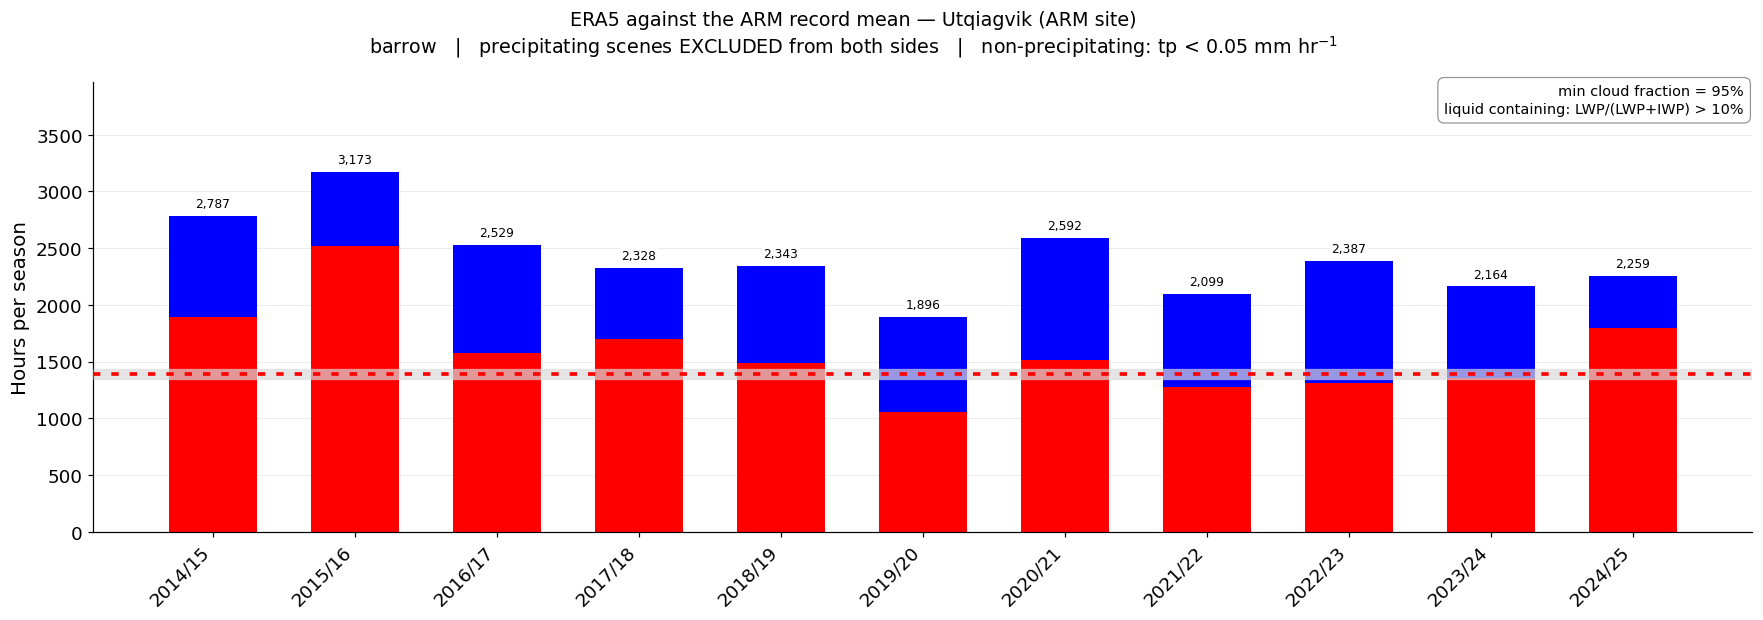

In [15]:
# The slide version: no legend, red dashed line on a light-grey halo, stacked
# bars. The line is the record mean from the saved observation file,
# following A_precip's precipitation filter.
lwph.fig_era5_vs_obs_simple_forOV(A_precip, out_dir=SAVE_DIR, halo_alpha=0.7);

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/halo_trials/barrow_era5_vs_obs_simple_OV_noprecip_mean2014-2024 - stacked - halo-alpha0.2-width2.5pt.png
  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/halo_trials/barrow_era5_vs_obs_simple_OV_noprecip_mean2014-2024 - stacked - halo-alpha0.35-width2.5pt.png
  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/halo_trials/barrow_era5_vs_obs_simple_OV_noprecip_mean2014-2024 - stacked.png
  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/halo_trials/barrow_era5_vs_obs_simple_OV_noprecip_mean2014-2024 - stacked - halo-alpha0.65-width2.5pt.png


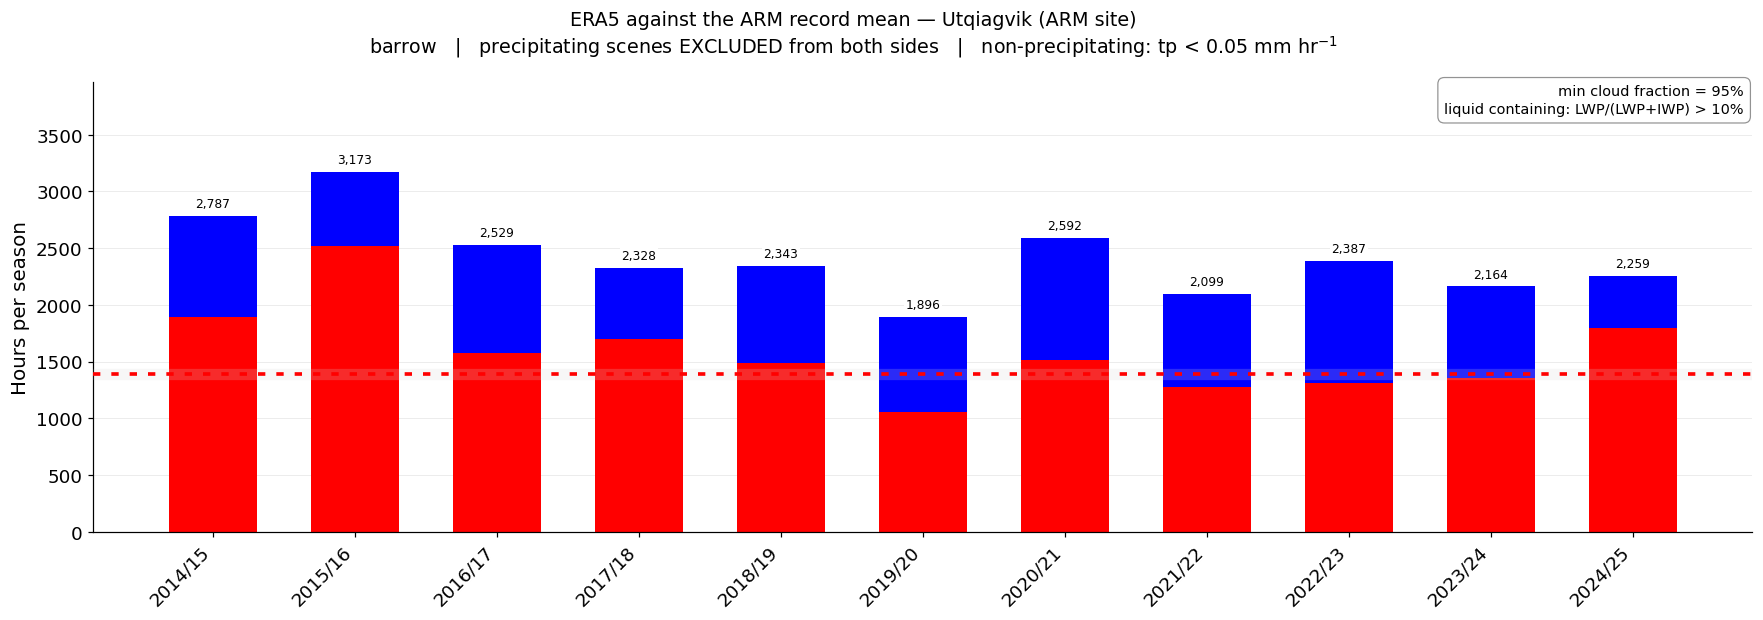

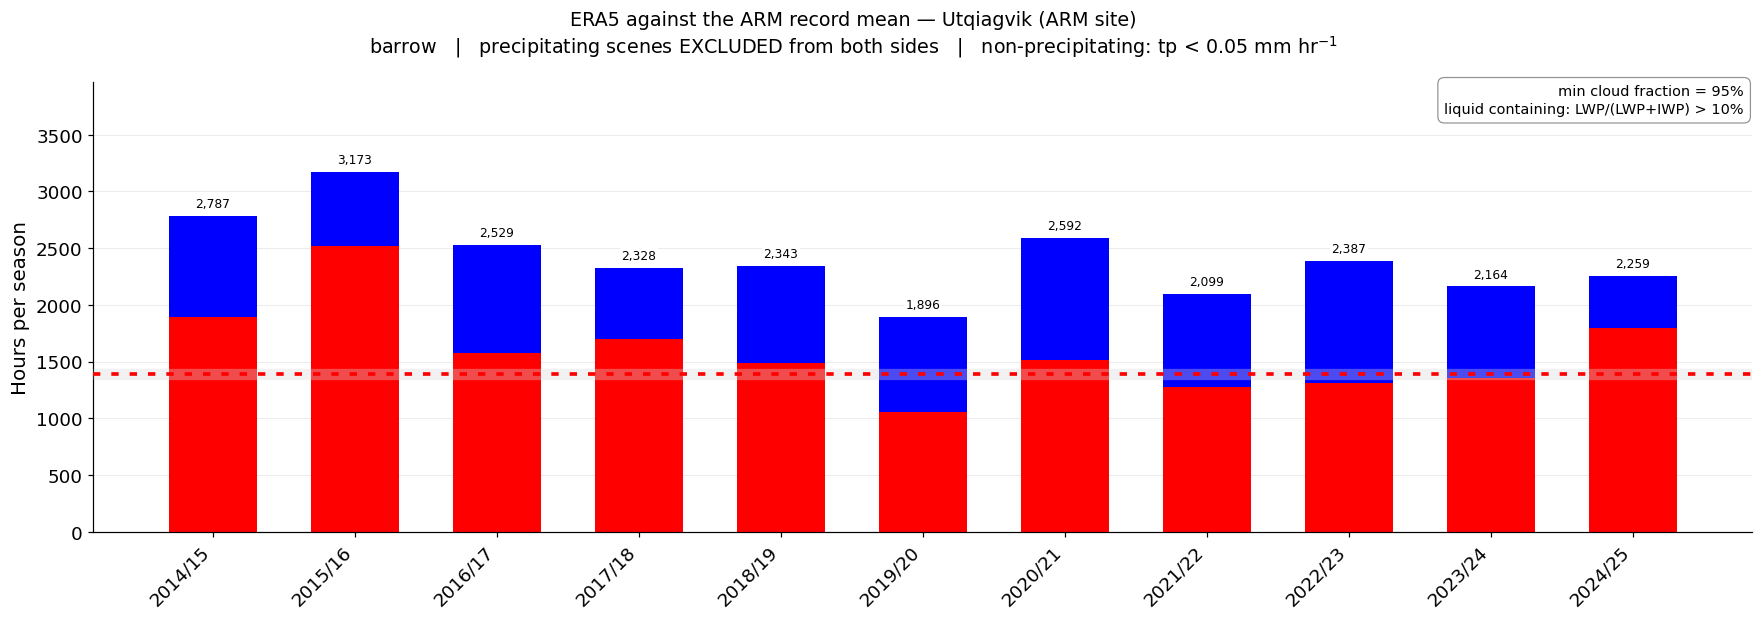

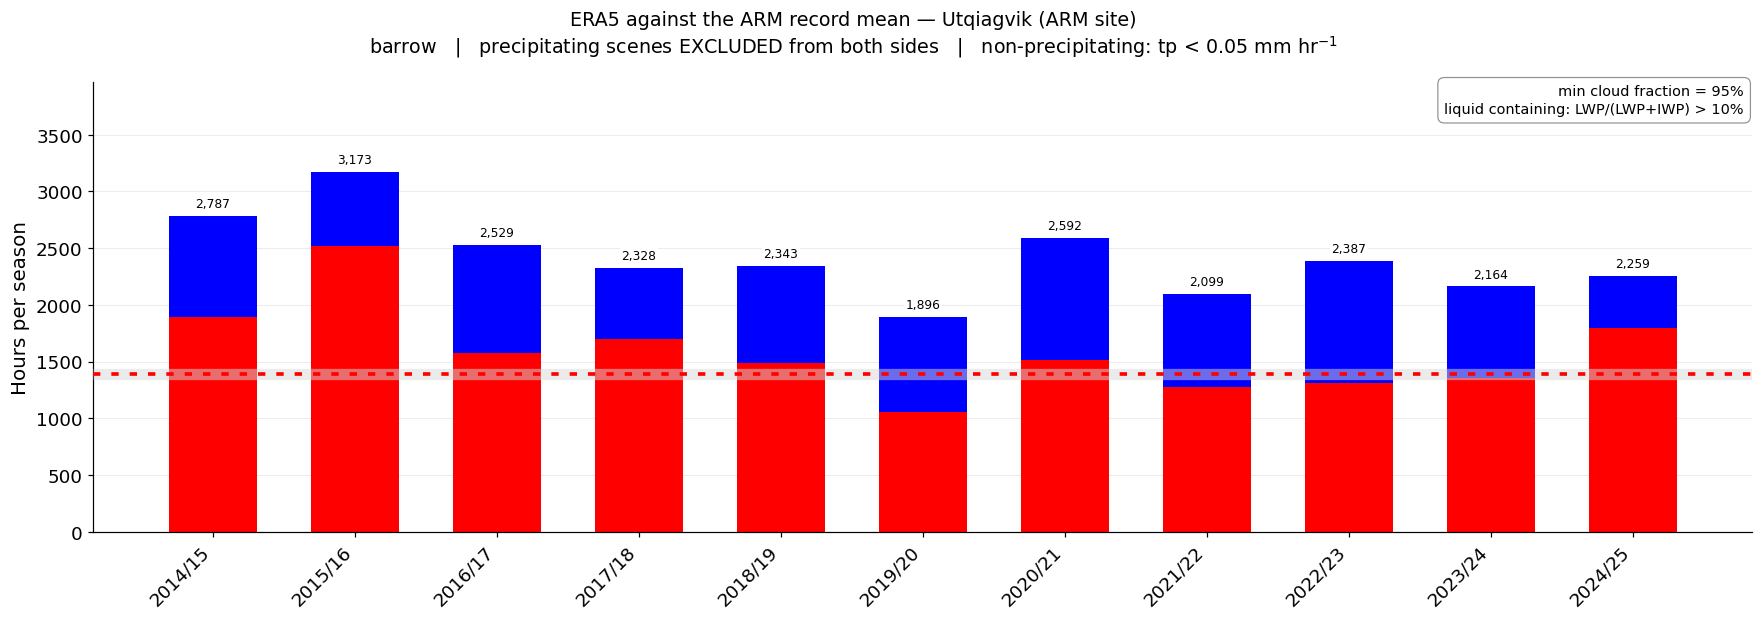

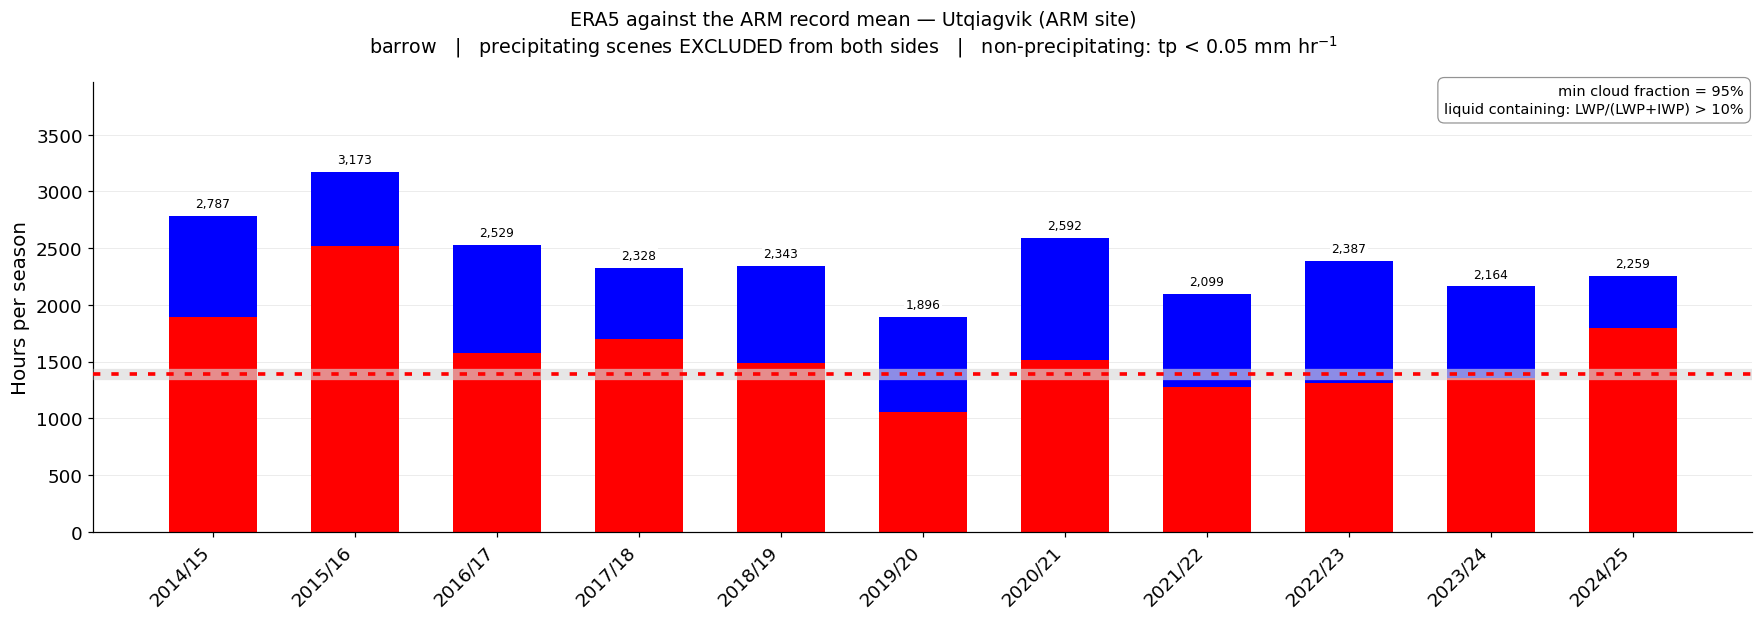

In [16]:
# Halo trials: the same figure at several opacities, to pick one by eye. Set
# the choice as the default with prepare(..., halo_alpha=...) -- the
# --halo-alpha option -- or pass it to the call above. Saved to a subfolder,
# each under its own suffix, so the main figures folder holds only the
# talk's version.
HALO_ALPHAS = (0.2, 0.35, 0.5, 0.65)

for alpha in HALO_ALPHAS:
    lwph.fig_era5_vs_obs_simple_forOV(A_precip, halo_alpha=alpha,
                                      out_dir=SAVE_DIR / "halo_trials")

### The numbers behind the line

Season by season, ERA5's liquid-containing hours against the observations
**two ways**: against that season's own observed hours (`ARM [h]`, from the
same ver3 table as the figure, with the run's precipitation pairing), and
against the **one** observed mean the line is drawn at (`ARM mean [h]`). Both
percent differences are normalised by the observed quantity,

$$
\%\,\text{diff} = 100\,\frac{\text{ERA5}_{\text{liq}} - \text{ARM}}{\text{ARM}} ,
$$

so a positive value means ERA5 has more liquid-containing hours. The two
columns answer different questions: against the season's own value the
difference is the model–observation mismatch for that winter; against the
record mean it also carries the observed record's own interannual
variability — a winter observed to be unusually cloudy sits above the mean
whatever ERA5 did. Reading them side by side separates the two.

Starred seasons are the incomplete observed seasons (missing > 5% of the
window): their observed hours are a lower bound, so their per-season percent
difference is biased high, and they are left out of the record mean. The two
closing rows are the means over every paired season and over the complete
seasons alone — in the second, ERA5 is averaged over the **same** eight
seasons, which is the like-for-like average, and the `ARM [h]` entry
reproduces the line value. Same arguments as the figure, so the ARM mean
printed is the line drawn.

In [18]:
pct_tbl = lwph.print_era5_vs_obs_mean_pct_diff(A_precip)


  Liquid-containing cloud hours per season, ERA5 (Utqiagvik (ARM site)) against the ARM observations
  non-precipitating pairing   |   ARM record mean 1,392 h/season (mean of 8 complete seasons; 3 incomplete excluded)
  % diff = 100 (ERA5 - ARM) / ARM, against that season's observation and against the record mean

    season               ERA5 [h]   ARM [h]   % diff    ARM mean [h]   % diff
    2014/15                 1,896     1,227   +54.5%           1,392   +36.2%
    2015/16                 2,517     1,875   +34.2%           1,392   +80.8%
    2016/17*                1,578     1,238   +27.4%           1,392   +13.3%
    2017/18                 1,704     1,310   +30.1%           1,392   +22.4%
    2018/19                 1,489     1,084   +37.4%           1,392    +6.9%
    2019/20*                1,059     1,205   -12.1%           1,392   -23.9%
    2020/21*                1,513       752  +101.3%           1,392    +8.7%
    2021/22                 1,276     1,356    -5.9%       

## Figure 2 — Monthly distributions, box and whisker

Per month, two boxes: ERA5 on the left as a **solid** red box, the
observations from Genie's spreadsheet (`genie_arm_monthly_hours.xlsx`, tab
`SUMMARY`) on the right in **dotted** lines. Each box is the interquartile
range across seasons, the line inside it the median, and the whiskers reach
the minimum and maximum — `whis=(0, 100)`, so no season is drawn as an
outlier. The count under each month is the number of seasons behind the box;
the months Genie highlighted as missing are dropped from **both** sides,
which makes it vary from 9 to 11.

**The slide version.** `fig_monthly_box_era5_vs_obs_build_forOV` draws
`fig_monthly_box_era5_vs_obs_forOV`, a separate copy of the working
`fig_monthly_box_era5_vs_obs`, kept so this figure can be edited for the
talk without touching the working one. It differs from the working figure in
four ways: the line styles are **swapped** — ERA5 is the solid box and the
observations the dotted one, so ERA5 reads as the solid red on every slide,
as in figure 1; the ERA5 fill is drawn at **full opacity**
(`fill_alpha=1.0`), so its red is the same red as figure 1's bars (the
working figure fills its solid box at alpha 0.28, which is why that red
looks lighter); there is **no legend**; and the threshold box is set in from
the y axis (`threshold_box_xy`, upper-left corner in axes fractions).
`threshold_box=False` drops the box. It saves under its own stem
(`monthly_box_OV_…`).

Three frames for the slide build: observations alone, then ERA5 beside them
(these two share one bounding box and overlay exactly), then the
median-difference panel added at its own size. Files carry ` - build1-obs`,
` - build2-both` and ` - build3-full` suffixes.

Source: `comparison_with_Genie_Obs.ipynb`, section 7b.

**Which observations, and which ERA5 run.** `obs_source` picks between
Genie's two monthly products, and the ERA5 run must match:

| `obs_source` | the observations | pair with |
|---|---|---|
| `"xlsx"` | `genie_arm_monthly_hours.xlsx` (her `SLCCounts_monthly_allSky.xlsx`) — **all sky**, both categories | `A_allsky` |
| `"noprecip"` | `genie_arm_monthly_hours_noprecip.csv` (her `SLC_counts_byMonth_…_precipitationFiltered.csv`, 2026-09-21) — **precipitating scenes removed**, liquid-containing only | `A_precip` |

The figure refuses a mismatched pair rather than drawing one silently
(`allow_precip_mismatch=True` overrides and states the mismatch on the
figure). The no-precip source has no ice-only category, so
`category="ice_only"` raises with it — use the spreadsheet for that. Its
monthly means are far lower than the all-sky ones (October 331 h against
500 h), which is the precipitation filter, not a different record.

**Which months are missing.** Both files describe the same ARM record, so
the months Genie highlighted in the spreadsheet (`GENIE_EXCLUDED_MONTHS`,
7 of them) still apply to the filtered CSV even where it carries a number —
and the CSV leaves **Dec 2018** blank, which is missing data too (confirmed
2026-09-22). The loader therefore marks a season-month missing when it is
blank, zero, or on Genie's flagged list, and the figure drops the **union**
from both sides: 8 months, leaving n = 9, 9, 9, 10, 10, 11 for Oct–Mar. Two
of the flagged months are the shortest in the file (Oct 2020 at 57 h,
Dec 2020 at 32 h), which is what a partly observed month looks like — a
check that the flags and this file agree about the record.

One month worth a look: **Feb 2017 carries just 7 h** and is neither blank
nor flagged, so it is currently kept.

  note: genie_arm_monthly_hours_noprecip.csv is also missing 1 season-month(s) [(2018, 12)]; dropped from both sides.
  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_monthly_box_OV_liquid_containing_era5_vs_obs_noprecip_mean2014-2024 - build1-obs.png
  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_monthly_box_OV_liquid_containing_era5_vs_obs_noprecip_mean2014-2024 - build2-both.png
  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_monthly_box_OV_liquid_containing_era5_vs_obs_noprecip_mean2014-2024 - build3-full.png


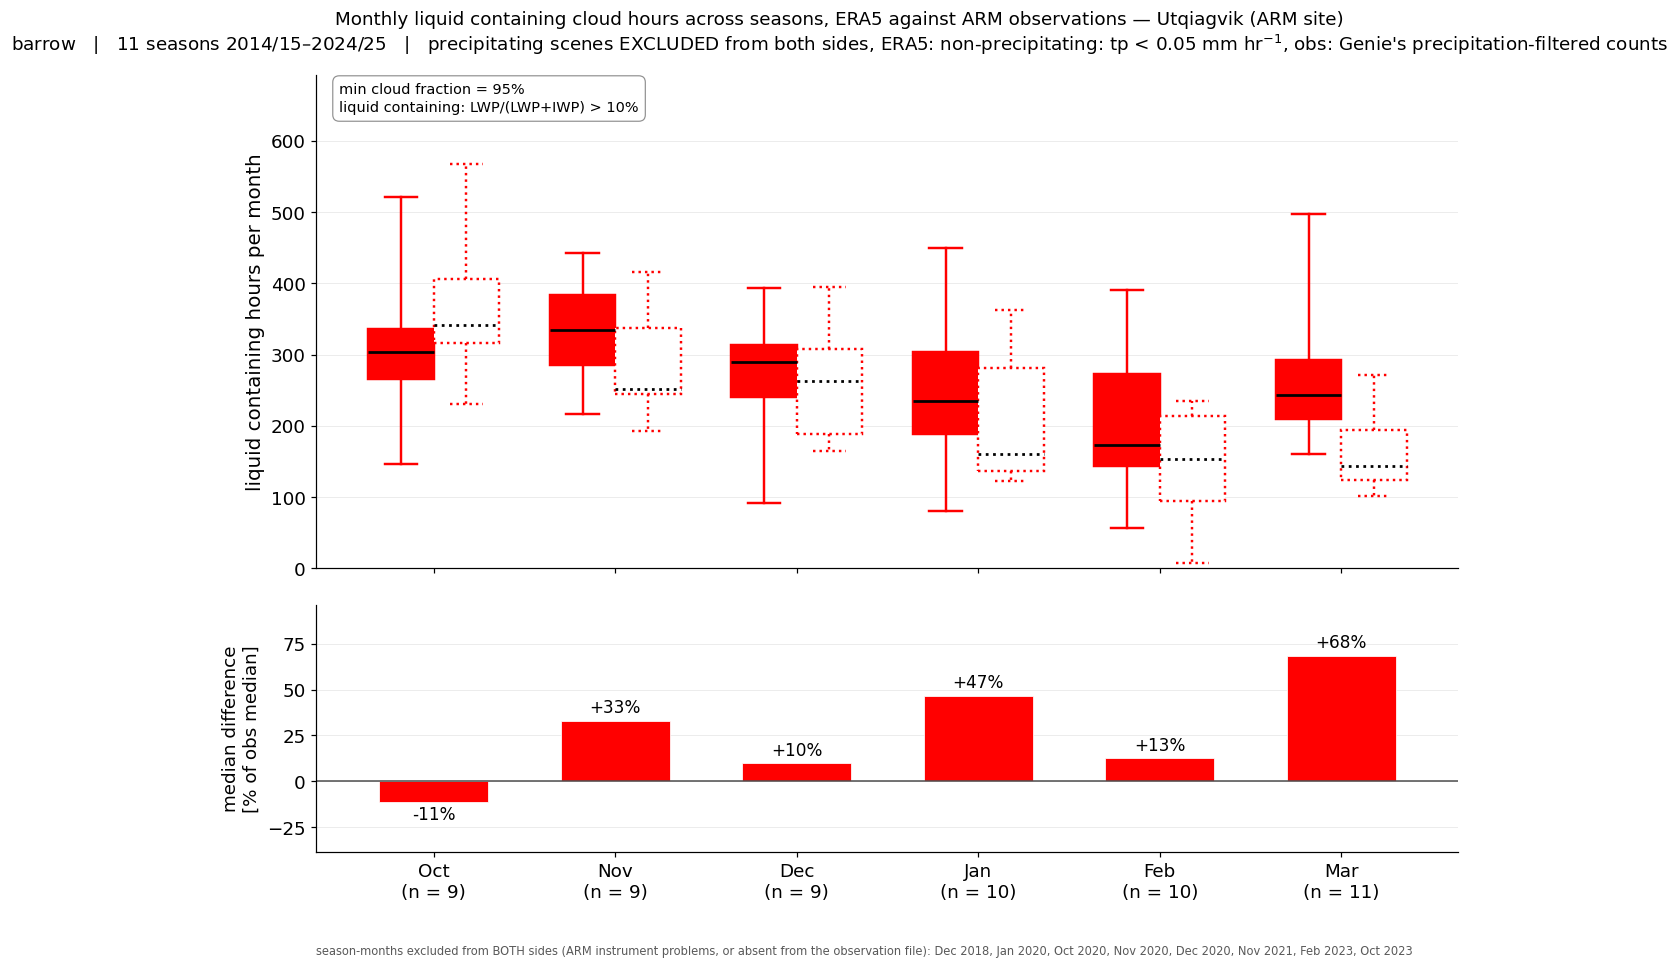

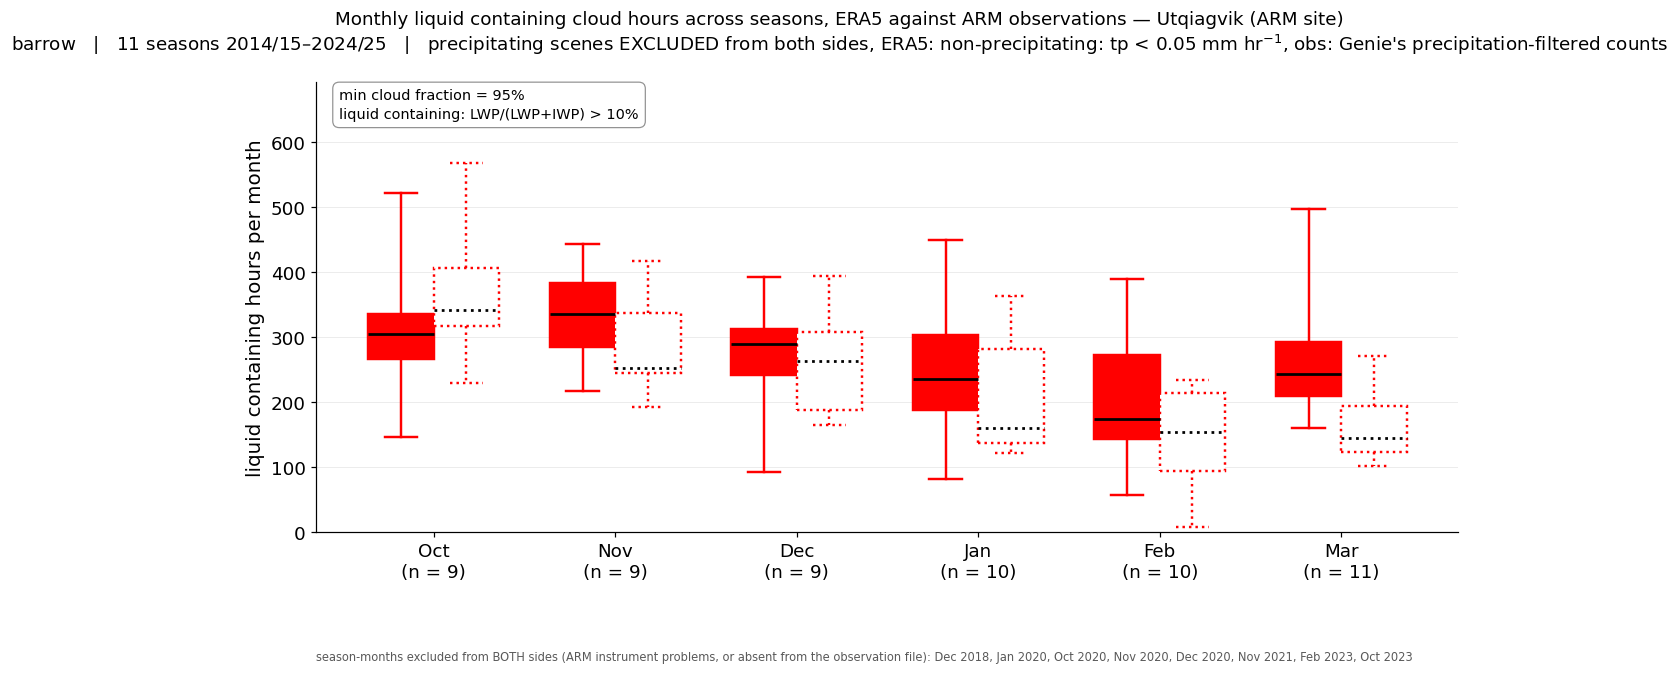

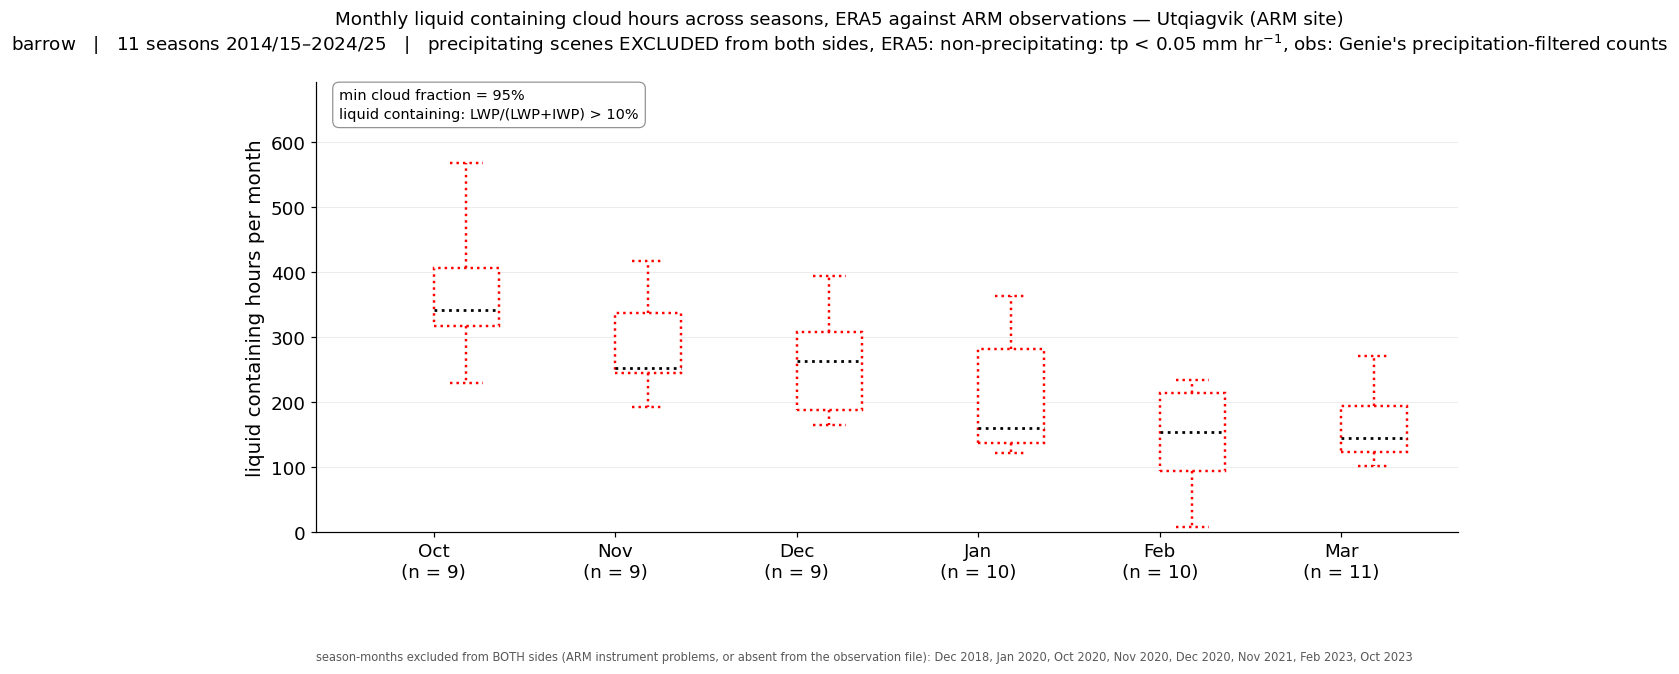

In [19]:
# Genie supplies two monthly products, and the ERA5 run has to match the one
# chosen: her all-sky spreadsheet pairs with A_allsky, her precipitation-
# filtered counts (2026-09-21) with A_precip. The pairing is read off the
# module's own table, so it cannot drift from the guard inside the figure,
# which refuses a mismatched pair. Also settable for a whole run with
# prepare(monthly_obs_source=...) / --monthly-obs-source.
MONTHLY_OBS_SOURCE = "noprecip"      # "xlsx" for the all-sky pairing

A_monthly = (A_allsky if lwph.MONTHLY_OBS_INCLUDES_PRECIP[MONTHLY_OBS_SOURCE]
             else A_precip)

# Liquid containing -- the primary quantity. The slide version: ERA5 solid
# red at full opacity, observations dotted, saved under the OV stem.
b_obs, b_both, b_full = lwph.fig_monthly_box_era5_vs_obs_build_forOV(
    A_monthly, out_dir=SAVE_DIR, category="liquid_containing",
    obs_source=MONTHLY_OBS_SOURCE)

## Figure 3 — Liquid retention by quality knob, ERA5 against the ARM record

One knob per panel, both records on it. **(a)** the minimum LWP a scene
must carry to count as liquid containing; **(b)** the minimum duration of a
liquid-containing cloud event, in hours. Observations are the solid line with
filled circles; ERA5 is the dashed line with open circles. Each curve is
normalised to its own unfiltered value, so both leave the left edge at 100%
and the y axis reads directly as the cost of the threshold.

The observational LWP curve is read from `genie_arm_retained_fraction.txt`
(section 6b of the `northSlope_alaska_doeARM` susceptibility notebook). The
observational **duration** curve is computed by the module itself from
Genie's per-cloud duration list (`genie_arm_cloud_durations.txt`, section 9f
of the same notebook, from her `cloudDuration_ALL.csv` of 2026-09-17) with
the same rule the ERA5 sweep uses: drop every cloud shorter than the
threshold, sum what is left. That replaced (2026-09-18) a curve derived from
her earlier 5-min binned histogram, which had been a different segmentation
of the record and made the duration knob look far more expensive than the
list says it is.

Below 1 h ERA5 has no curve — its shortest resolvable event is one hour — so
the observed fall inside the first hour has nothing to be compared against.
From 1 h to the end of the observational record both resolve the same
threshold and the comparison is point for point. Pass `dur_xmax_h=8` to zoom
the duration axis onto that overlap.

Source: `plot_lwp_threshold_sweep.ipynb`, section 8, *one panel per knob*.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_liquid_retention_by_knob_mean2014-2024.png


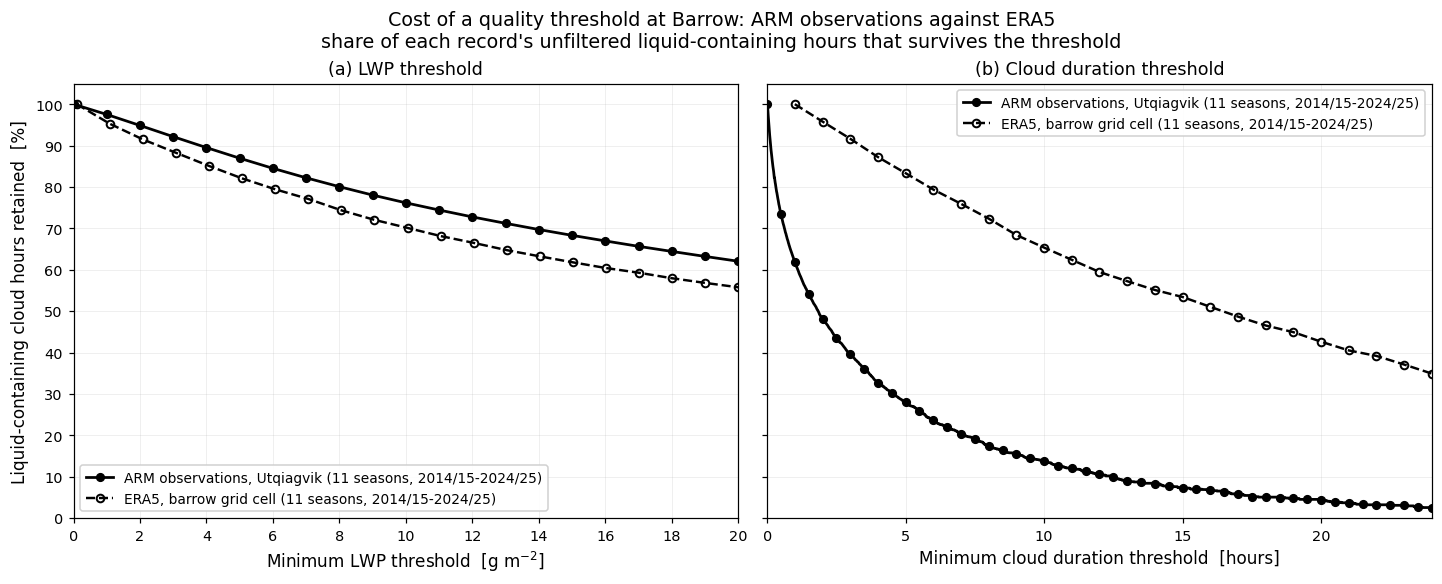

In [ ]:
lwph.fig_liquid_retention_by_knob(A_sweep, out_dir=SAVE_DIR);

## Figure 4 — Cloud duration and in-cloud wind speed at the ARM cell

Two histograms on one set of axes, each with **its own x axis along the
bottom**, coloured to match: the duration of ERA5's liquid-containing
**events** at the Utqiaġvik grid cell (dark blue; a maximal run of
consecutive liquid-containing hours, so 1 h is the shortest and the axis is
in hours), and the wind speed at the cell's liquid-containing **hours** (teal,
the lower of the two axes). The y axis is the share of samples in each bin,
so one distribution of events and one of hours sit on a common footing.
Dashed lines mark the medians.

**Which wind.** `--wind-source` / `wind_source=` picks it:

| source | wind | seasons |
|---|---|---|
| `"cloud"` **(default)** | liquid-mass-weighted wind at cloud level, from the pressure-level archive (`clw.cloud_level_wind`, section 6 of the working notebook) | 2024/25–2025/26 only — the archive's span |
| `"10m"` | the single-level 10 m wind | all eleven, the same population as the durations |

With `"cloud"` the two histograms span **different seasons**, and the legend
says so; the duration histogram always comes from the eleven-season run. The
10 m wind is a lower bound on the wind at cloud level under a stable Arctic
boundary layer — section 6 of the working notebook puts the median ratio
$U_{cl}/U_{10}$ at the cell from the two seasons both exist for.

**Which duration.** `--duration-mode` / `duration_mode=` picks what the
dark-blue histogram counts:

| mode | one sample per | axis |
|---|---|---|
| `"event"` **(default)** | liquid-containing **event** — a maximal run of consecutive liquid-containing hours — with its duration | 0–48 h (`dur_xmax_h`) |
| `"daily"` | calendar **day** with its liquid-containing hours, days with none included at 0 | 0–24 h |

The daily histogram is the distribution behind the hours-per-day table
below: its mean is the table's pooled h/day, and its spike at 0 is the share
of days with no liquid-containing hour at all. Censored events (runs touching
a hole in the archive or a season boundary) are kept in the event histogram:
their length is a lower bound, and dropping them would remove the long clouds
preferentially. Files carry both settings in the stem
(`cloudDuration_andWind_OV_<event|daily>_<cloud|10m>`).

Source: `cloud_spatial_extent.ipynb`, sections 2 (events) and 6 (cloud-level
wind).


  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_cloudDuration_andWind_OV_event_cloud_noprecip0p05mmhr_mean2014-2024.png


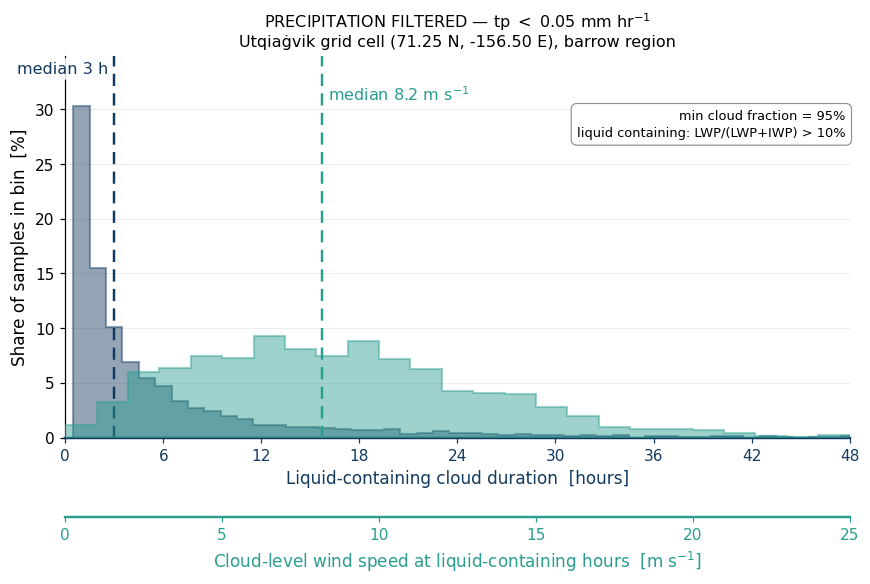

In [ ]:
# Default: the cloud-level wind (2024/25-2025/26) beside the eleven-season
# durations. wind_source="10m" draws the 10 m wind over all eleven seasons.
clw.fig_cloudDuration_andWind_forOV(E, ev, E_pl=E_pl, CL=CL, out_dir=SAVE_DIR);


  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_cloudDuration_andWind_OV_event_10m_noprecip0p05mmhr_mean2014-2024.png


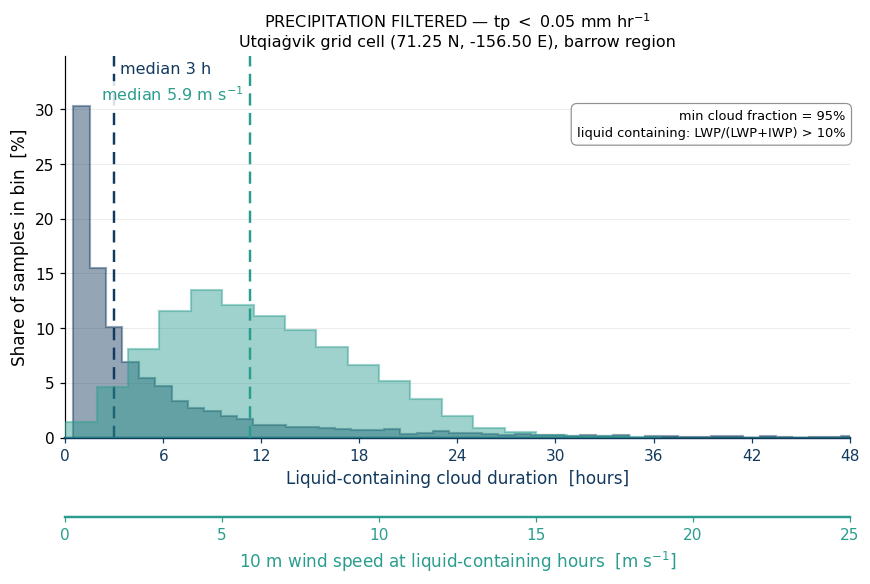

In [ ]:
# The 10 m variant: same seasons as the durations, lower bound on the wind.
clw.fig_cloudDuration_andWind_forOV(E, ev, wind_source="10m", out_dir=SAVE_DIR);


  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_cloudDuration_andWind_OV_daily_10m_noprecip0p05mmhr_mean2014-2024.png


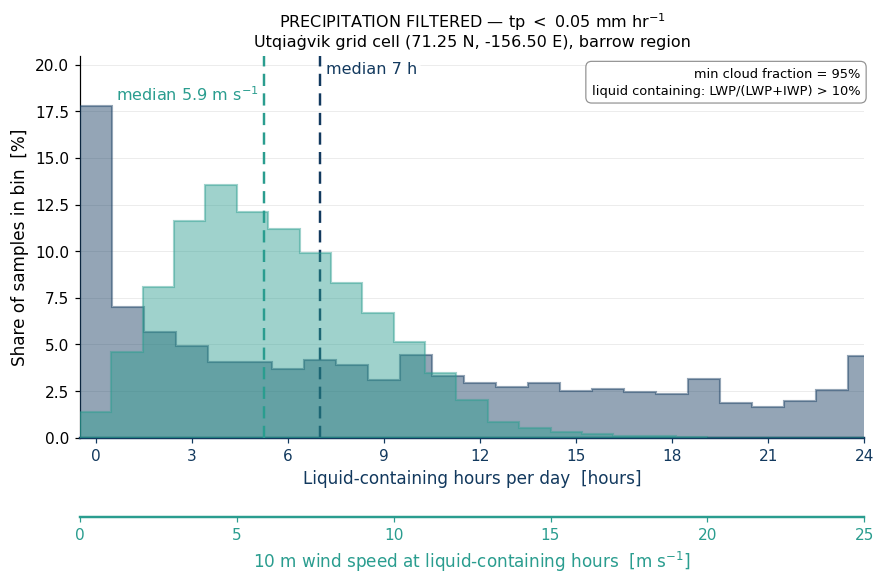

In [ ]:
# Hours per day instead of event duration: one sample per calendar day,
# days with no liquid-containing hour included at 0. Same wind as the default.
clw.fig_cloudDuration_andWind_forOV(E, ev, E_pl=E_pl, CL=CL, duration_mode="daily",
                                    out_dir=SAVE_DIR, wind_source="10m");


### Liquid-containing hours per grid-cell day, by month — and the length of cloud that implies

**Upper block.** At the same grid cell: the liquid-containing hours in each
month of the window, summed over the eleven seasons, divided by the number of
days that month contributed — hours of liquid-containing cloud per day,
October through March. Equivalent to 24 × the month's liquid-containing
fraction of hours, and printed both ways, with the lowest and highest
single-season rate beside each month for the spread. The closing row pools
every month. Same run and filter as the figure.

**Lower block, below the rule.** Taylor's frozen-turbulence hypothesis turns
that time into a length: if the cloud field is frozen and simply advected,
the along-wind length of liquid-containing cloud that passes over the cell in
a day is

$$
\ell_{\text{day}} = \underbrace{(\text{h/day} \times 3600\ \text{s h}^{-1})}_{\text{seconds of liquid cloud per day}} \times \tilde{U} ,
$$

with $\tilde{U}$ the **median** wind speed over the cell's liquid-containing
hours in that month (all months pooled for the closing row), printed beside
it with the number of hours behind it. The wind follows the same
`--wind-source` / `wind_source=` toggle as the figure: `"cloud"` (default) is
the liquid-mass-weighted cloud-level wind, available for 2024/25–2025/26 only
— the table then says so, since the h/day column is still the eleven-season
rate — and `"10m"` is the 10 m wind over all eleven seasons, a lower bound.
For all months, 8.20 h/day is 29,516 s of liquid cloud per day; at the
cloud-level median of 8.2 m s⁻¹ that is ~240 km of cloud per day, at the 10 m
median of 5.8 m s⁻¹ ~170 km.


In [ ]:
# Default: cloud-level wind (E_pl, CL). wind_source="10m" uses the 10 m wind
# in E over all eleven seasons instead.
hpd_tbl = cse.print_site_liquid_hours_per_day(E, E_pl=E_pl, CL=CL, wind_source="10m")


Liquid-containing hours per day at the ARM grid cell (71.25 N, -156.50 E), barrow region
2014/15–2024/25, 11 seasons   |   non-precipitating: tp < 0.05 mm hr$^{-1}$   |   tcc >= 0.95

  month    liquid h   days  h / day  % of hours  season min  season max
  Oct         3,255    341     9.55       39.8%        4.71       16.81
  Nov         3,703    330    11.22       46.8%        7.23       14.77
  Dec         2,852    341     8.36       34.8%        2.97       12.68
  Jan         2,543    341     7.46       31.1%        2.61       14.48
  Feb         2,137    311     6.87       28.6%        2.04       13.45
  Mar         3,001    341     8.80       36.7%        5.16       16.03
  all        17,491   2005     8.72       36.3%

  h / day = liquid-containing hours in the month over all seasons, divided by the days
  the month contributed; the last two columns are the same rate in the lowest and
  highest single season.

  ------------------------------------------------------------------

### Figure 4-alt — Distribution of the Taylor horizontal extent

The previous figure 4, kept as the alternative. Method 1 of the extent
notebook. At every cell, a maximal run of consecutive liquid-containing hours
is one **event**, and its horizontal extent follows Taylor's hypothesis,

$$
L = U_{10}\,\Delta t ,
$$

with $U_{10}$ the mean 10 m wind speed over the run and $\Delta t$ its
duration. One count per event, domain-wide and at the ARM cell, on
log-spaced bins over a log axis: a one-hour event in light wind gives a few
km, a multi-day run thousands. The 10 m wind is slower than the wind at
cloud level, so read $L$ as a lower bound — section 6 of the working notebook
quantifies the ratio from the pressure-level archive.

Source: `cloud_spatial_extent.ipynb`, section 2, *The distribution of L*.


  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_taylor_hist_L_km_noprecip0p05mmhr_mean2014-2024.png


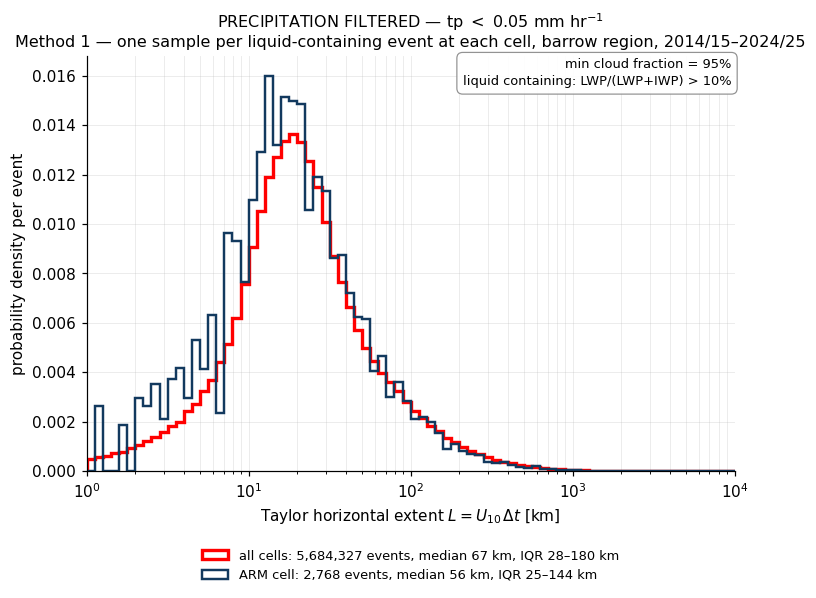

In [ ]:
cse.fig_taylor_hist(E, ev, out_dir=SAVE_DIR);

## Figure 5 — How often, and how much liquid — side by side

The season-mean liquid-containing fraction beside the mean LWP of those
clouds, per cell. The two need not vary together: a cell can have liquid
cloud often but thin, or rarely but thick, and the pair separates the two.
The LWP panel is the mean over **every** liquid-containing hour across
seasons — weighted by each season's hour count, not a mean of season means.
Both maps carry latitude/longitude ticks and a margin legend naming the red
star (the ARM cell). Drawn once per run, all sky and precipitation filtered.

Source: `map_liquid_containing_hours.ipynb`, section 5b.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_map_fraction_and_lwp_allsky_mean2014-2024.png
  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_map_fraction_and_lwp_noprecip0p05mmhr_mean2014-2024.png


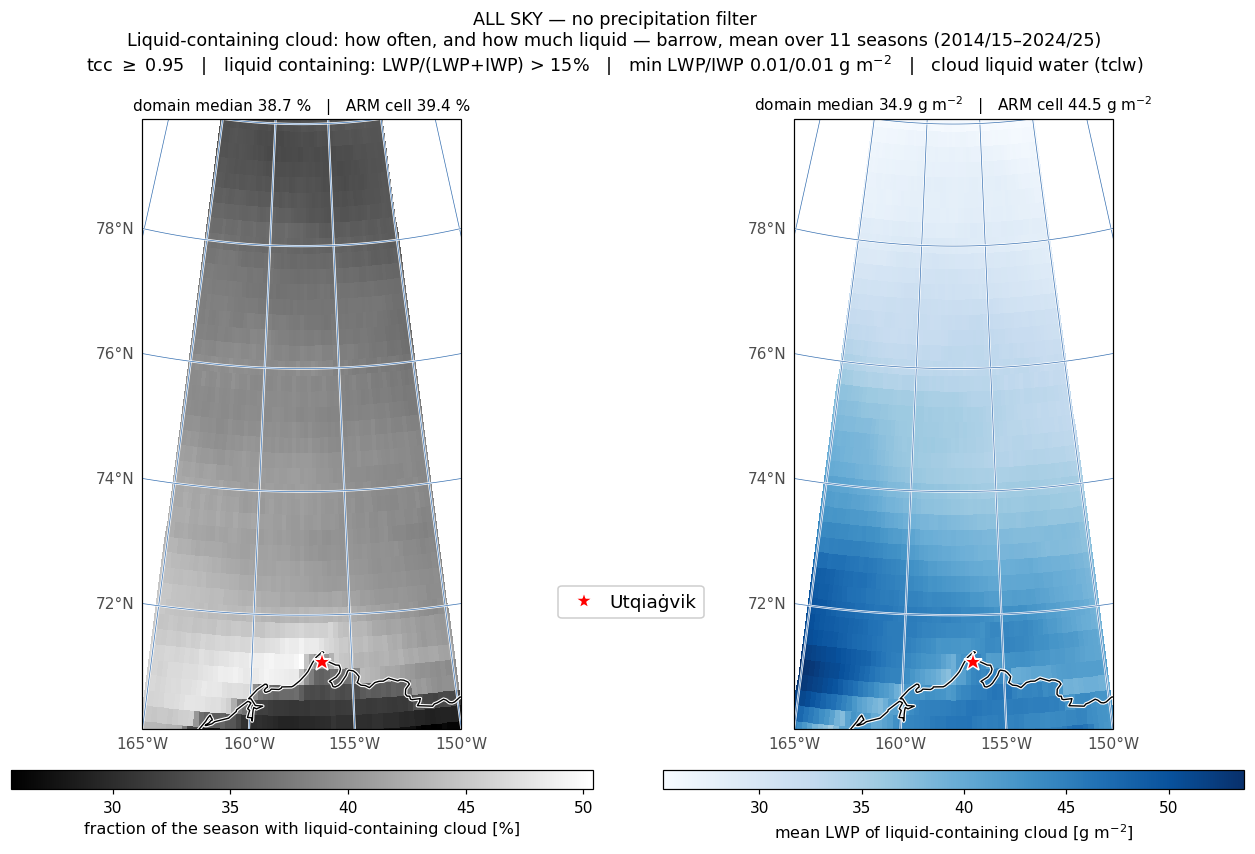

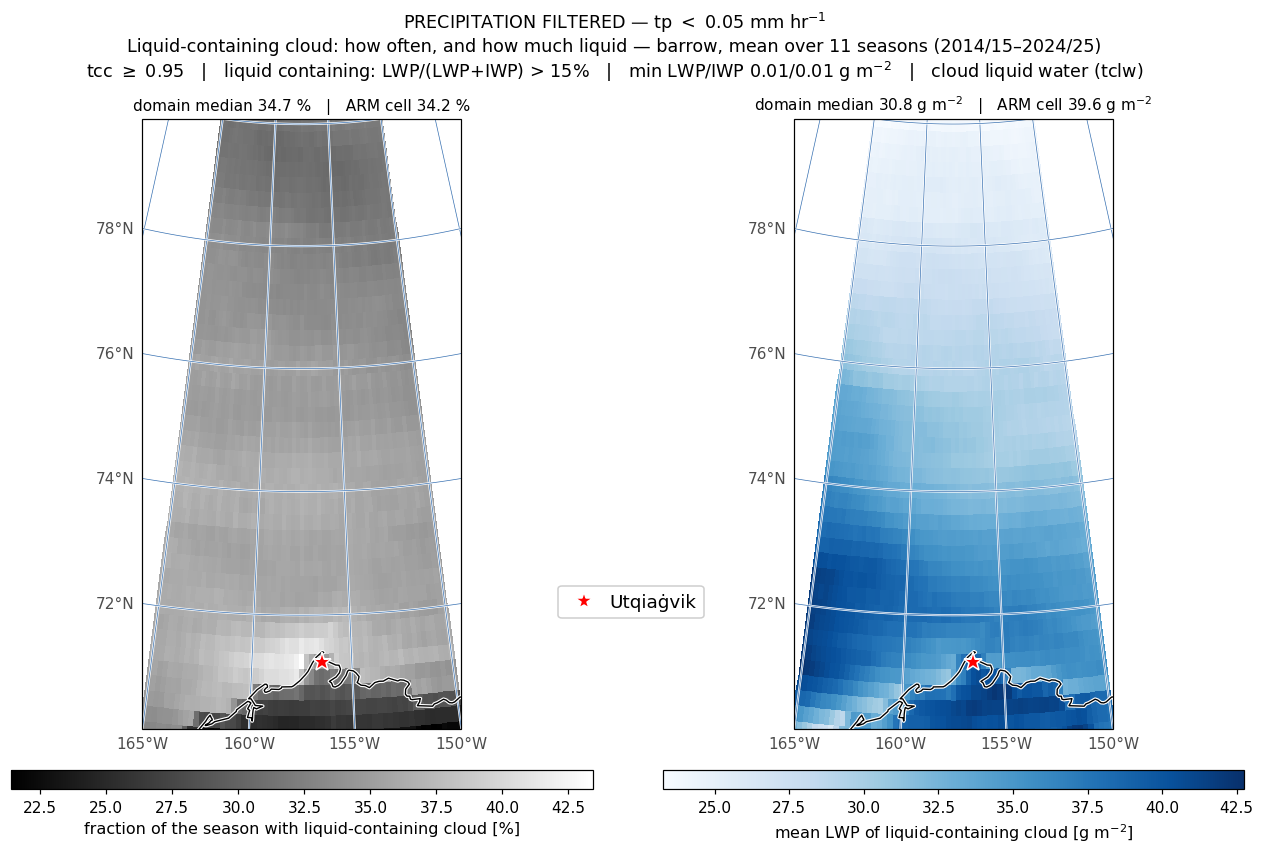

In [ ]:
for tag, Mi in MAP_RUNS:
    mlh.fig_fraction_and_lwp(Mi, out_dir=SAVE_DIR)

## Figure 6 — One season month by month, with the ice edge

October through March of one season. **Top row:** fraction of the month with
liquid-containing cloud, per cell, on the same black-to-white scale as the
season maps — a partly sampled month reads as a rate, not a shortfall.
**Bottom row:** mean LWP over those hours, on the white-to-blue scale. Each
row has one colour scale across its six months.

On every panel, the monthly-mean sea ice concentration is contoured —
**dashed at 0.05**, where open water gives way to ice, and **solid at 0.95**,
where full pack ice begins. Those are the concentrations this project's
surface classes are cut at, so the lines are the boundaries between open
ocean, marginal ice zone and sea ice as the season freezes up.

Source: `map_liquid_containing_hours.ipynb`, section 5c.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_map_monthly_2024_allsky_mean2014-2024.png
  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_map_monthly_2024_noprecip0p05mmhr_mean2014-2024.png


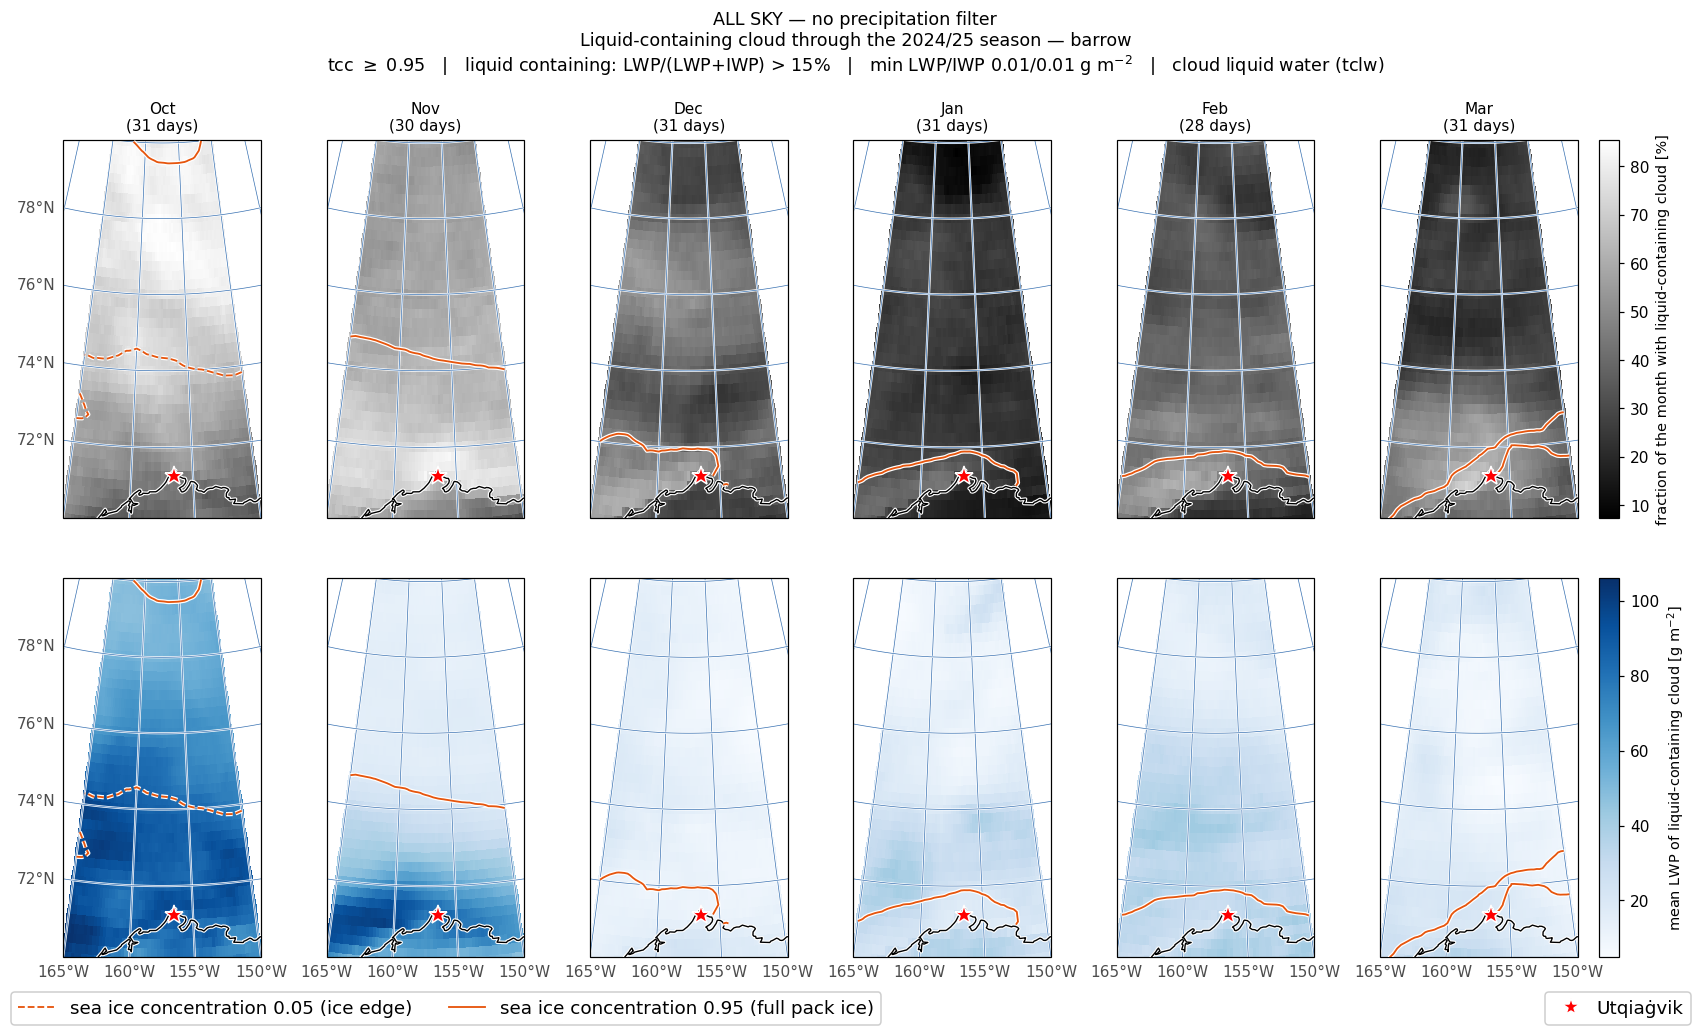

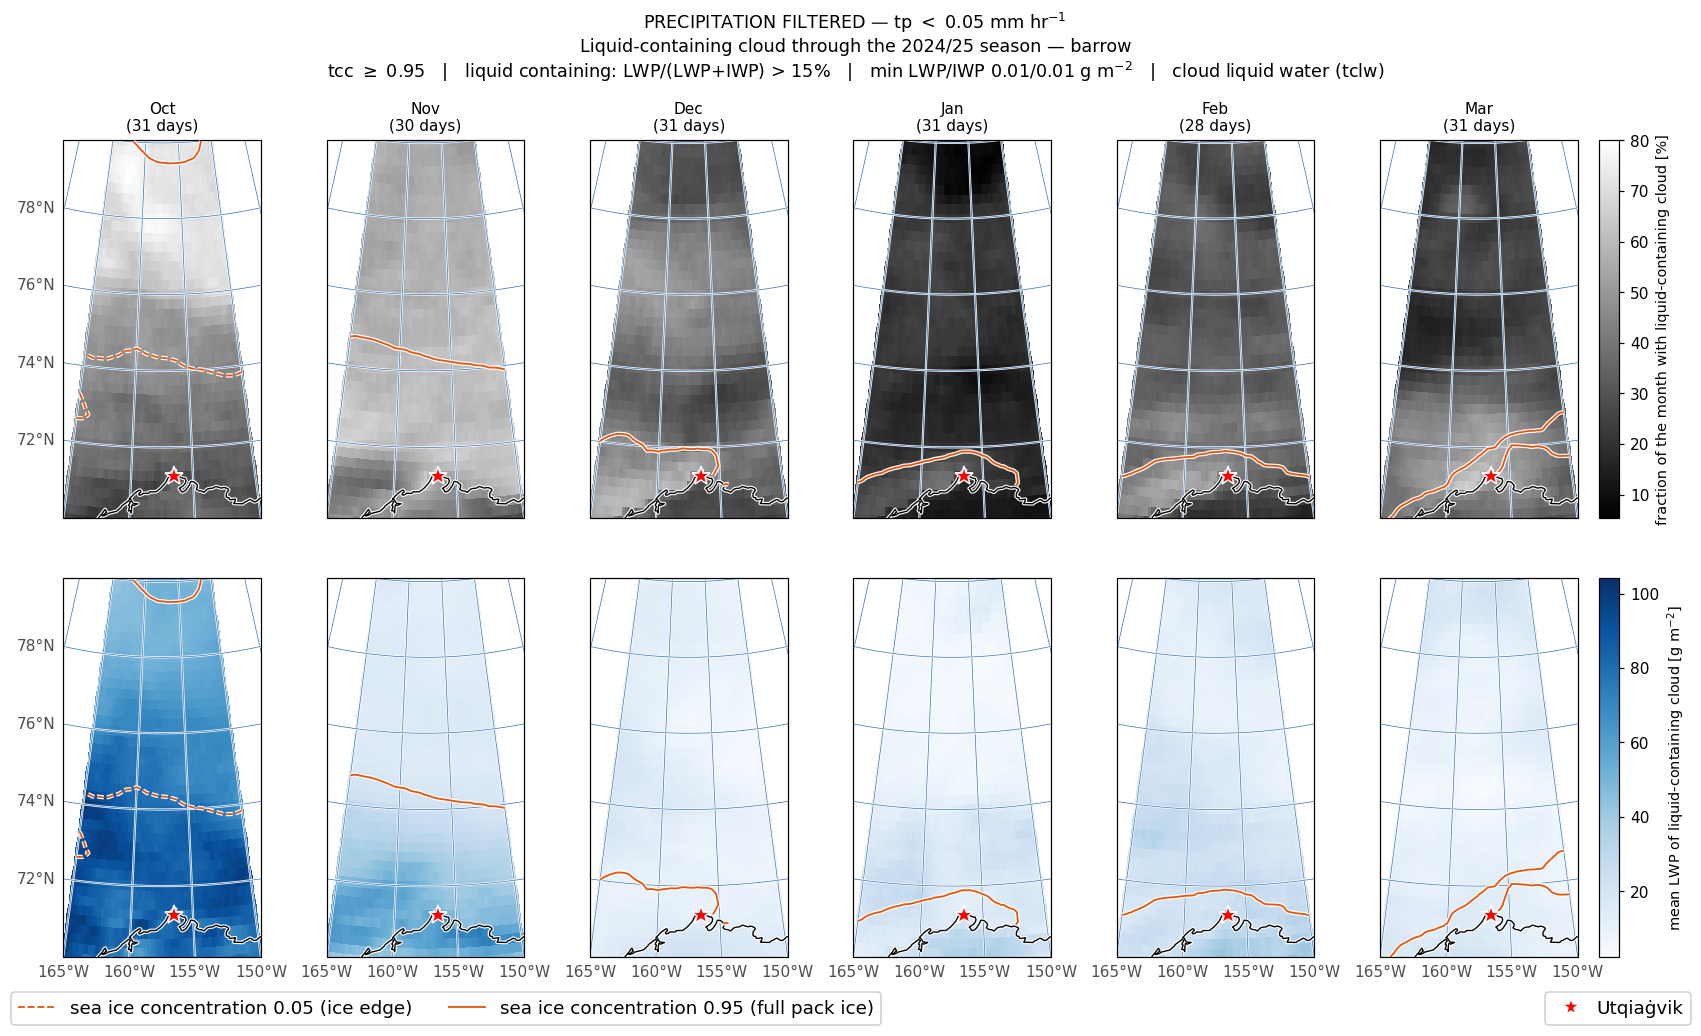

In [ ]:
SEASON = 2024      # season start year; any of M_all.used

for tag, Mi in MAP_RUNS:
    mlh.fig_season_monthly_maps(Mi, season=SEASON, out_dir=SAVE_DIR)

## Figure 7 — Downwelling longwave by sky state

What the liquid cloud does to the surface longwave budget, hour by hour, in
the same population figures 1–2 count. Per month, three boxes of hourly
downwelling longwave at the ARM cell: **liquid containing** (red),
**ice only** (blue) and **clear sky** (grey) — the first two in the colours of
figure 1's bars. Each box is the interquartile range over every such hour of
that month across the eleven seasons, the black line the median, whiskers
the full range with no outliers drawn; the hours behind each box are printed
beneath it.

**The three states** (`plot_dlr_by_phase.sky_state_masks`), from `A_precip`'s
thresholds:

| state | definition |
|---|---|
| liquid containing | `tcc ≥ 0.95`, cloud water above the minimum paths, `IWP/CWP < ice_fraction_min` |
| ice only | `tcc ≥ 0.95`, cloud water above the minimum paths, `IWP/CWP ≥ ice_fraction_min` |
| clear sky | `LWP ≤ min_lwp` **and** `IWP ≤ min_iwp`, **and** `tcc < 0.05` (`clear_tcc_max`) |

The precipitation filter (`tp < 0.05 mm hr⁻¹`) is applied to every state.
The states are exclusive but not exhaustive: partly cloudy hours
(0.05 ≤ tcc < 0.95) fall outside all three boxes, and the table reports how
many. The one deliberate departure from the hour-count figures is the
overcast-but-empty hours (tcc ≥ 0.95 with no cloud water above the floors):
figures 1–2 fold them into ice only so that liquid and ice sum to the
overcast total, but a scene with no condensate radiates like clear sky, so
here they are left out (12 hours in this run;
`fold_no_phase_into_ice=True` restores the other convention).

**Clear sky is rare in ERA5 at this cell, and the figure says so.** ERA5 puts
the grid cell below `tcc = 0.05` in about **1%** of cold-season hours —
roughly 500 hours in eleven seasons, against ~3,000 liquid-containing hours
per month — and only 13 in November and 29 in February. Boxes backed by
fewer than `min_hours` (30) are hatched. Relaxing the cover bound does not
change the picture much (`clear_tcc_max=0.2` admits ~2% of hours), because
ERA5 is overcast at this cell 71% of the time. For comparison, the ARM record
in `genie_arm_seasonal_hours.txt` averages **898 clear-sky hours per season**
(~20% of the window) — a point-instrument/grid-box difference in what "clear"
means, and possibly an ERA5 bias, either of which is worth a sentence if this
figure goes on a slide.

Source: new for this talk, `ERA5/surface_energy_budget/plot_dlr_by_phase.py`.

### 7a. The grid cell containing Utqiaġvik

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_monthly_dlr_box_by_phase_noprecip_mean2014-2024.png


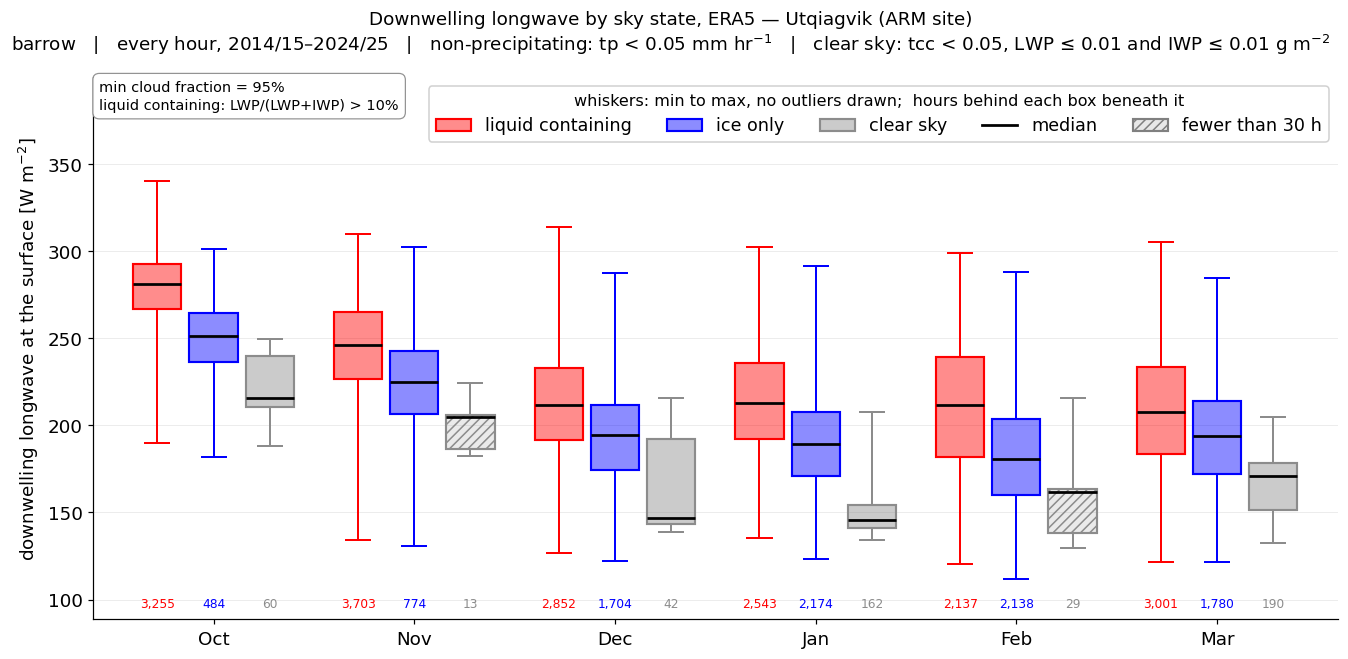

In [ ]:
# Every hour at the ARM cell, Oct-Mar 2014/15-2024/25, precipitation filtered.
# clear_tcc_max=, fold_no_phase_into_ice=, whis= and min_hours= are the knobs.
dlr.fig_monthly_dlr_box(A_precip, S_precip, out_dir=SAVE_DIR);

#### The numbers behind the boxes

Per month and state: hours, median, interquartile range and mean of the
downwelling longwave, then the median differences between states —
liquid − clear is the longwave effect of a liquid-containing overcast over a
clear sky at this cell, liquid − ice the part of it that phase alone buys.
The closing lines account for every hour after the filter: in the boxes, partly
cloudy, or overcast without condensate.

In [ ]:
dlr_tbl = dlr.print_monthly_dlr_table(A_precip, S_precip)


  Downwelling longwave at the surface [W m-2] by month and sky state, ERA5 (Utqiagvik (ARM site))
  non-precipitating (tp < 0.05 mm/hr)   |   11 seasons 2014/15–2024/25   |   clear sky: tcc < 0.05, LWP <= 0.01 and IWP <= 0.01 g m-2

    month                  liquid containing                          ice only                         clear sky   median differences [W m-2]
              hours  median         IQR mean    hours  median         IQR mean    hours  median         IQR mean  liq-ice  liq-clr  ice-clr  
    Oct       3,255   281.4   267-293    279      484   251.2   236-265    251       60   215.9   210-240    222    +30.1    +65.5    +35.3
    Nov       3,703   246.5   227-265    245      774   225.0   206-243    223       13   204.6   187-206    203    +21.4    +41.9    +20.5
    Dec       2,852   212.0   191-233    212    1,704   194.3   174-212    194       42   146.9   144-192    163    +17.7    +65.1    +47.4
    Jan       2,543   212.7   192-236    214    2,174   189.1 

### 7b. The whole Barrow domain

The same figure over every cell of the domain (41 × 61 cells, 70–80°N,
165–150°W) — land, coast, open ocean, marginal ice zone and pack ice
together. The statistics come from the 1 W m⁻² histograms, weighted by
cos(latitude); a quartile is exact to half a bin. The counts under the boxes
are plain cell-hours. Above each month's grouping, two numbers from the
tables below: $\Delta\mathrm{DLR}_{\mathrm{glaciated}}$, the
liquid-containing median minus the ice-only median, and
$\Delta\mathrm{DLR}_{\mathrm{clrsky}}$, the liquid-containing median minus
the clear-sky median (W m⁻², unit omitted). `show_differences=False` drops
them and puts the legend back inside the axes.

**The share of hours in each state** is the table below, for the domain and
the ARM cell side by side, under the run's precipitation filter and for all
hours. Domain-wide, over the eleven seasons, **3.0%** of non-precipitating
hours are clear sky by this definition (0.7% in October rising to 4.8% in
March), 41% liquid containing, 28% ice only and 28% partly cloudy
(0.05 ≤ tcc < 0.95). The ARM cell has less clear sky than the domain (1.2%)
and more partly cloudy time (36%). The domain-wide clear-sky boxes hold
100k–900k cell-hours per month, so none is thin; their medians sit at
147–160 W m⁻² from November on, against ~200 W m⁻² under liquid-containing
cloud — a median difference of 47–72 W m⁻².

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_monthly_dlr_box_by_phase_domain_noprecip_mean2014-2024.png


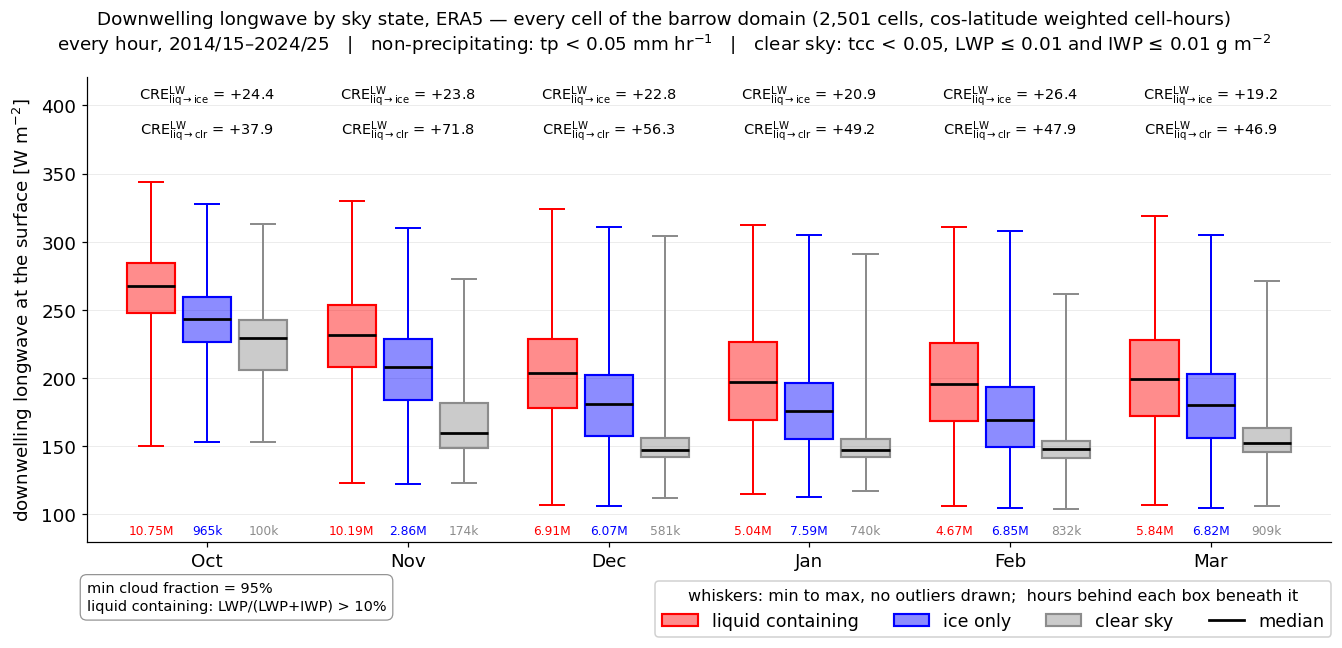

In [ ]:
dlr.fig_monthly_dlr_box_domain(A_precip, D_precip, out_dir=SAVE_DIR);

**The slide version**, for comparison: the same eighteen boxes without the
difference annotations, hour counts, legend or threshold box, with the
colours spelled out on the subtitle line; 16:9-ish canvas and larger fonts.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_monthly_dlr_box_by_phase_domain_OV_noprecip_mean2014-2024.png


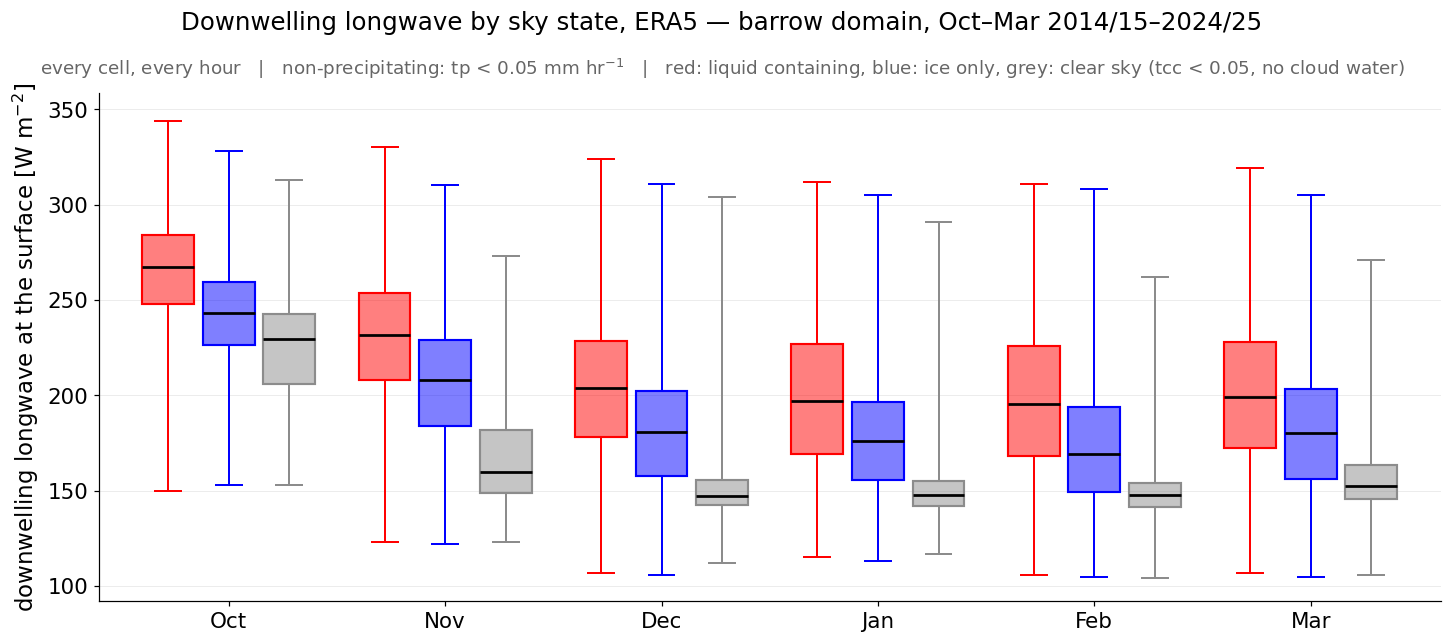

In [ ]:
dlr.fig_monthly_dlr_box_domain_forOV(A_precip, D_precip, out_dir=SAVE_DIR);

#### By surface class — land, open ocean and sea ice

The domain figure split by the surface under each cell-hour, one row per
class, from the run's own classification (`lsm` for land, and the hour's sea
ice concentration cut at 0.05 and 0.95 for open ocean and pack ice). Each row
has its own flux axis; the month axis, legend and threshold box are shared.
Open ocean exists only in October–December in this domain — it freezes over
by January — so its later months are empty by construction, not missing, and
the legend and threshold box use that space (`legend_in="open_ocean"`; any
row's name, or `None` to put them below the bottom row).
Coastal and marginal-ice-zone cells are left out here; pass
`classes=("land", "coastal", "open_ocean", "marginal_ice", "sea_ice")` for
all five.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_monthly_dlr_box_by_phase_by_class_noprecip_mean2014-2024.png


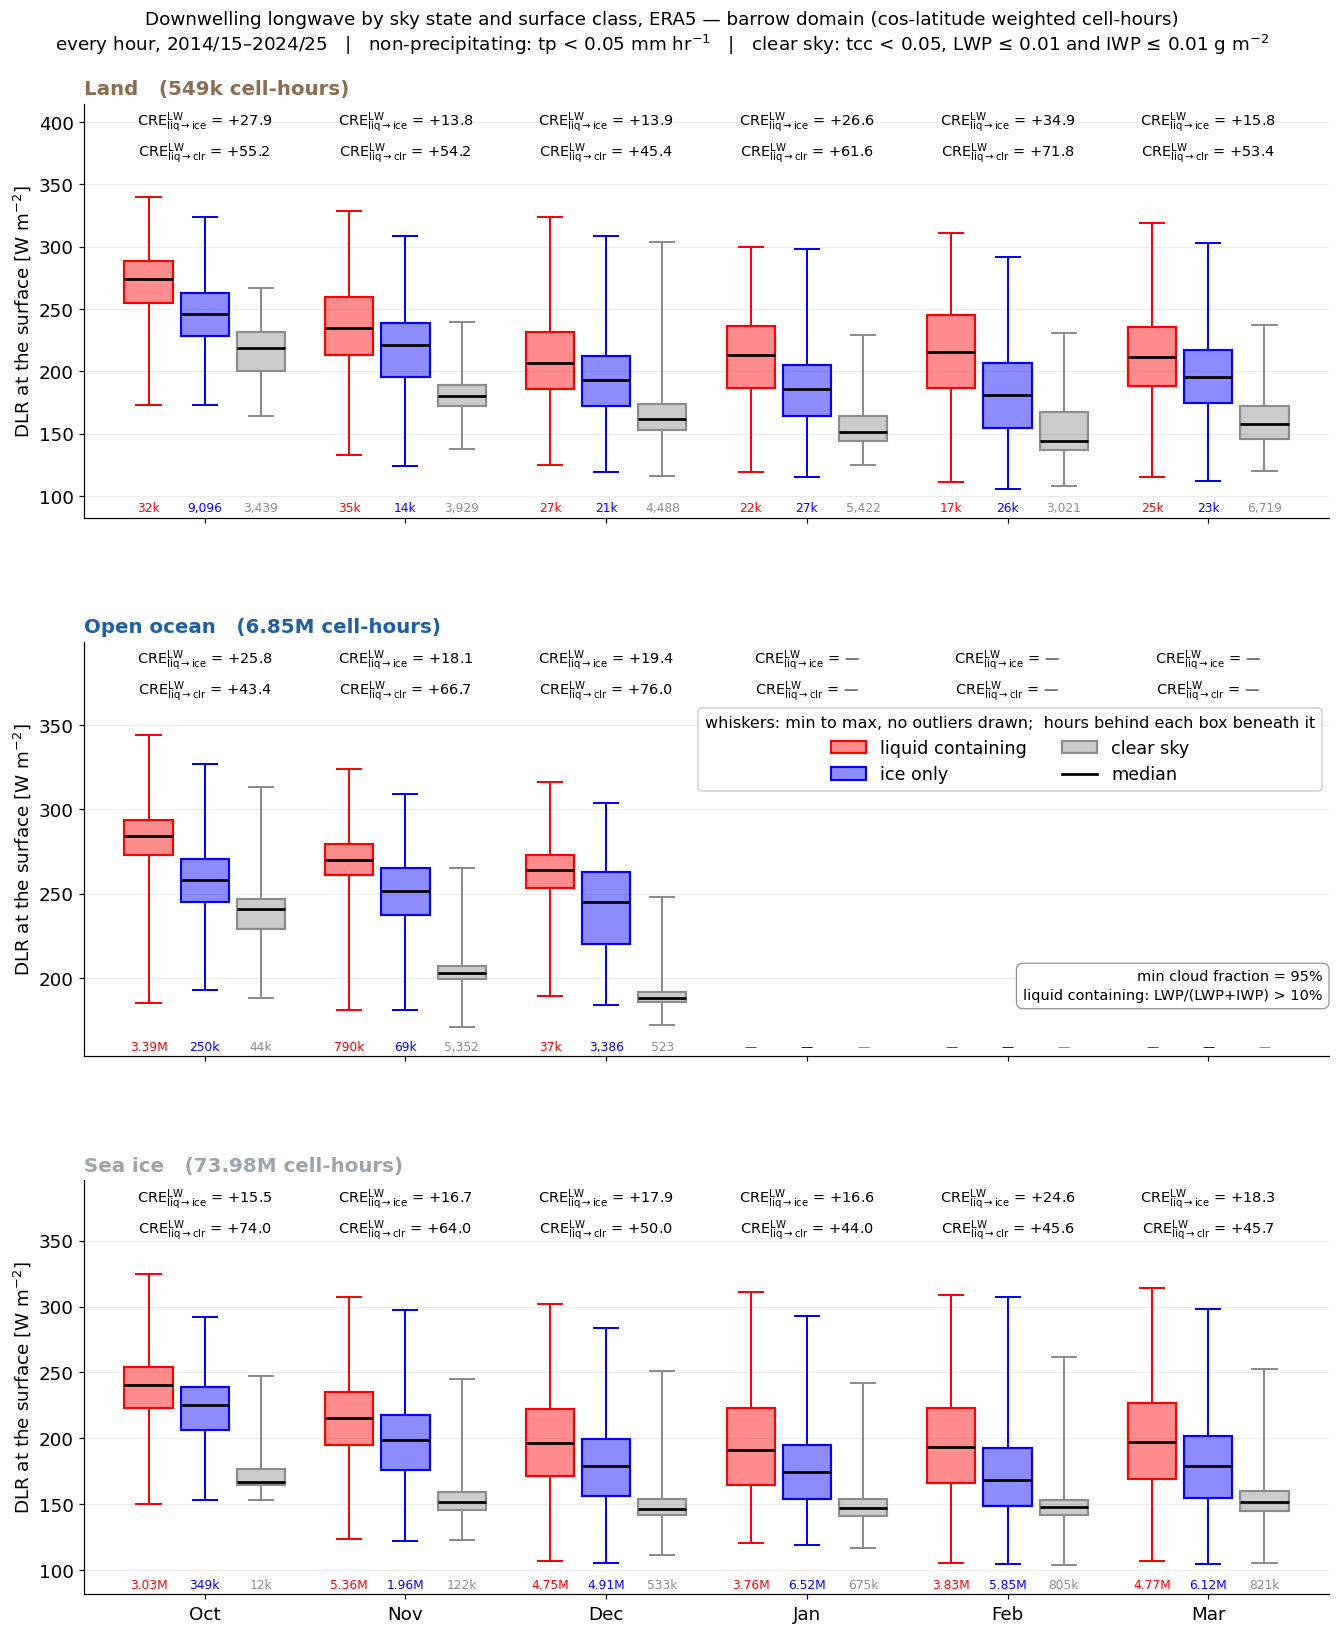

In [ ]:
dlr.fig_monthly_dlr_box_by_class(A_precip, D_precip, out_dir=SAVE_DIR);

**The slide version**, for comparison: the same rows without the difference
annotations, hour counts, legend or threshold box; one shared flux axis so a
box reads across surfaces as well as months; the colours spelled out on the
subtitle line instead of a legend; 16:9-ish canvas and larger fonts. Thin
boxes (< 30 h) would still be hatched. `show_title=False` drops the two title
lines for a slide that carries its own.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_monthly_dlr_box_by_phase_by_class_OV_noprecip_mean2014-2024.png


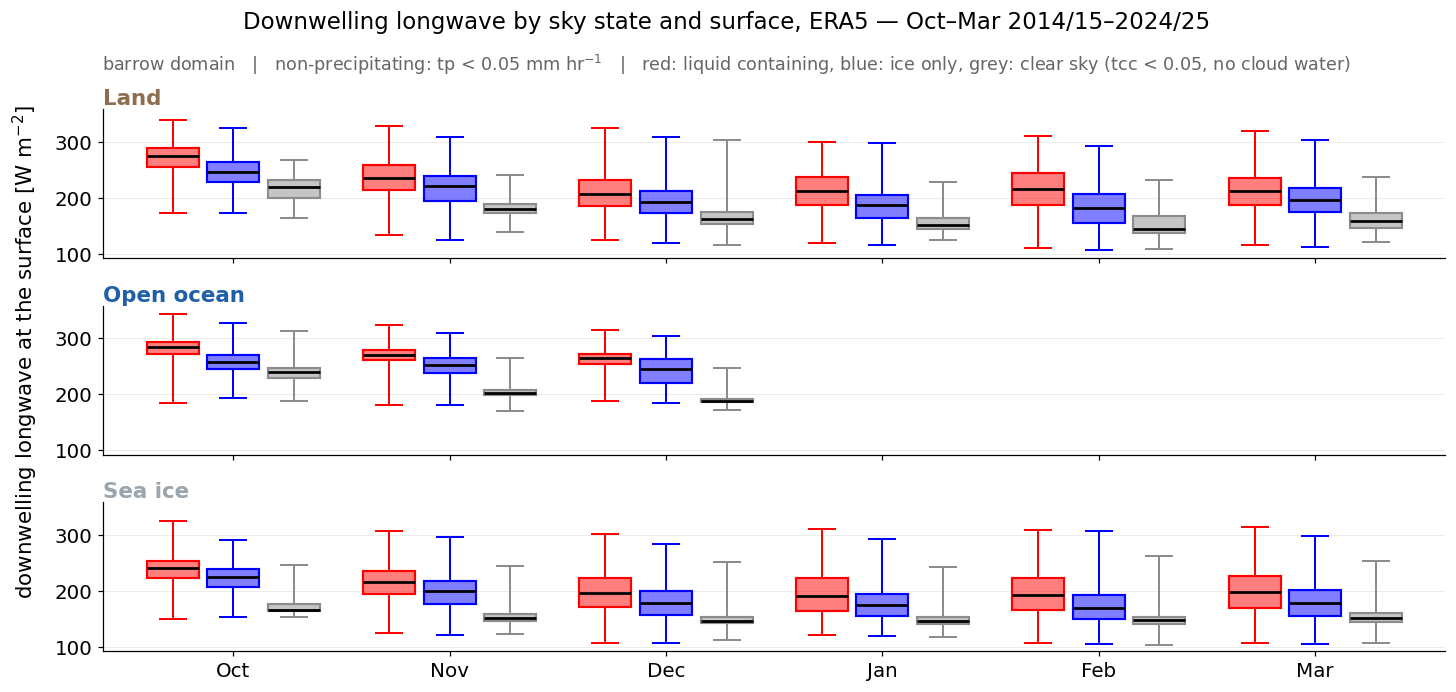

In [ ]:
dlr.fig_monthly_dlr_box_by_class_forOV(A_precip, D_precip, out_dir=SAVE_DIR);

#### ver2 — open ocean and sea ice, with what liquid cloud adds beneath, three ways

`fig_monthly_dlr_box_by_class_forOV_ver2`: the slide figure for open ocean
and sea ice (class titles a few points larger), and beneath each class a row
of two boxes per month — $\Delta\mathrm{DLR}_{\mathrm{glaciated}}$
(liquid containing − ice only, in the ice-only blue) and
$\Delta\mathrm{DLR}_{\mathrm{clrsky}}$ (liquid containing − clear sky, in the
clear-sky grey). How the differences are formed is a switch, `method=` on
the call or `--dlr-diff-method` / `prepare(dlr_diff_method=...)` for the
run (`dlr_differences` does the work):

| method | one value per | what is differenced |
|---|---|---|
| `median_diff` (default) | season | the class's monthly medians, liquid − ice and liquid − clear |
| `daily_diff` | day | the class's daily medians over its cells that day (the "same day, same surface" pairing); days with < 20 cell-hours in either state dropped |
| `cre` | season | each hour's **cloud radiative effect** DLR − DLR$_{\mathrm{clear}}$, using ERA5's own clear-sky flux `msdwlwrfcs`; the class's median CRE under liquid minus under ice (under clear, ≈ 0) |
| `cre_matched` | season | as `cre`, but liquid and ice (clear) hours are compared only **within the same 10 W m⁻² bin of clear-sky flux** — the same air-mass emission state — and the per-bin differences are averaged with the liquid hours' bin weights |

**Which to trust.** `median_diff` and `daily_diff` both compare *different
hours*, and the hours that hold liquid cloud sit in different air masses
from those that hold ice cloud or clear sky — warmer and moister on the
seasonal scale (the composition effect above), but within a day the
contrast can run either way. `cre` compares every hour **with its own
atmosphere with the cloud removed**, so the air-mass difference between the
populations is removed by construction; what is left is what the cloud
itself adds, which is the quantity the row is meant to show. The check
that the reference is fair is `print_cre_check`: under clear sky the median
CRE should sit within a watt of zero, and it does (−0.5 to +0.9 W m⁻² on
the test run). On the 3-season test the three methods gave, for liquid −
ice over sea ice, roughly +8 to +33 (`median_diff`), +4 to +7
(`daily_diff`) and +5 to +15 W m⁻² (`cre`): the plain difference of medians
overstates the phase effect, and even same-day pairing does not isolate it.
`cre` still leaves one environmental effect in: the same cloud adds less
over a warm, moist column whose window is already partly closed. `cre_matched`
removes that too by comparing only within a clear-sky-flux bin, and it asks
the sharpest question — "in the environments where liquid cloud occurs, how
much more does it add than an ice cloud would in the same environment". On
the 3-season test it cut liquid − ice over sea ice to −1 to +8 W m⁻² (from
+5 to +15 for `cre`), while open ocean stayed at +24 to +30: over pack ice in
deep winter, ERA5's liquid-containing and ice-only clouds add nearly the same
longwave once the air mass is matched. Its caveat is **coverage**, printed by
`print_diff_methods_table`: the match for ice is 87–100% of liquid hours, but
for clear sky it is much lower where clear skies live in colder, drier columns
than liquid clouds do (17% over sea ice in October, ~50% over open ocean), so
the matched liquid − clear speaks for the liquid hours that *have* a clear
counterpart, not for the typical liquid hour. Read `cre_matched` for the
phase effect and `cre` for what liquid cloud adds over its own clear sky.
Boxes are over the 11 seasons (`median_diff`, `cre`, `cre_matched`) or over
the ~330 days of the month (`daily_diff`); a box with fewer than
`min_values` (5) values is hatched.


  Median cloud radiative effect DLR - DLR_clearsky [W m-2] by state (non-precipitating: tp < 0.05 mm hr$^{-1}$)
    month                           Land                    Open ocean                       Sea ice
              liquid       ice     clear    liquid       ice     clear    liquid       ice     clear
    Oct         63.8      37.5      -0.2      71.2      41.5      -0.1      59.9      48.3      -0.4
    Nov         54.1      42.0      -0.2      71.5      45.8       0.1      48.7      40.4      -0.2
    Dec         44.8      37.4      -0.2      72.5      35.7       0.9      38.2      30.2      -0.2
    Jan         44.5      35.9      -0.2        --        --        --      31.8      25.9      -0.3
    Feb         43.0      31.5      -0.2        --        --        --      34.0      22.6      -0.3
    Mar         41.9      36.0      -0.2        --        --        --      36.9      27.5      -0.3

  Liquid containing minus ice only / minus clear sky [W m-2], median of each m

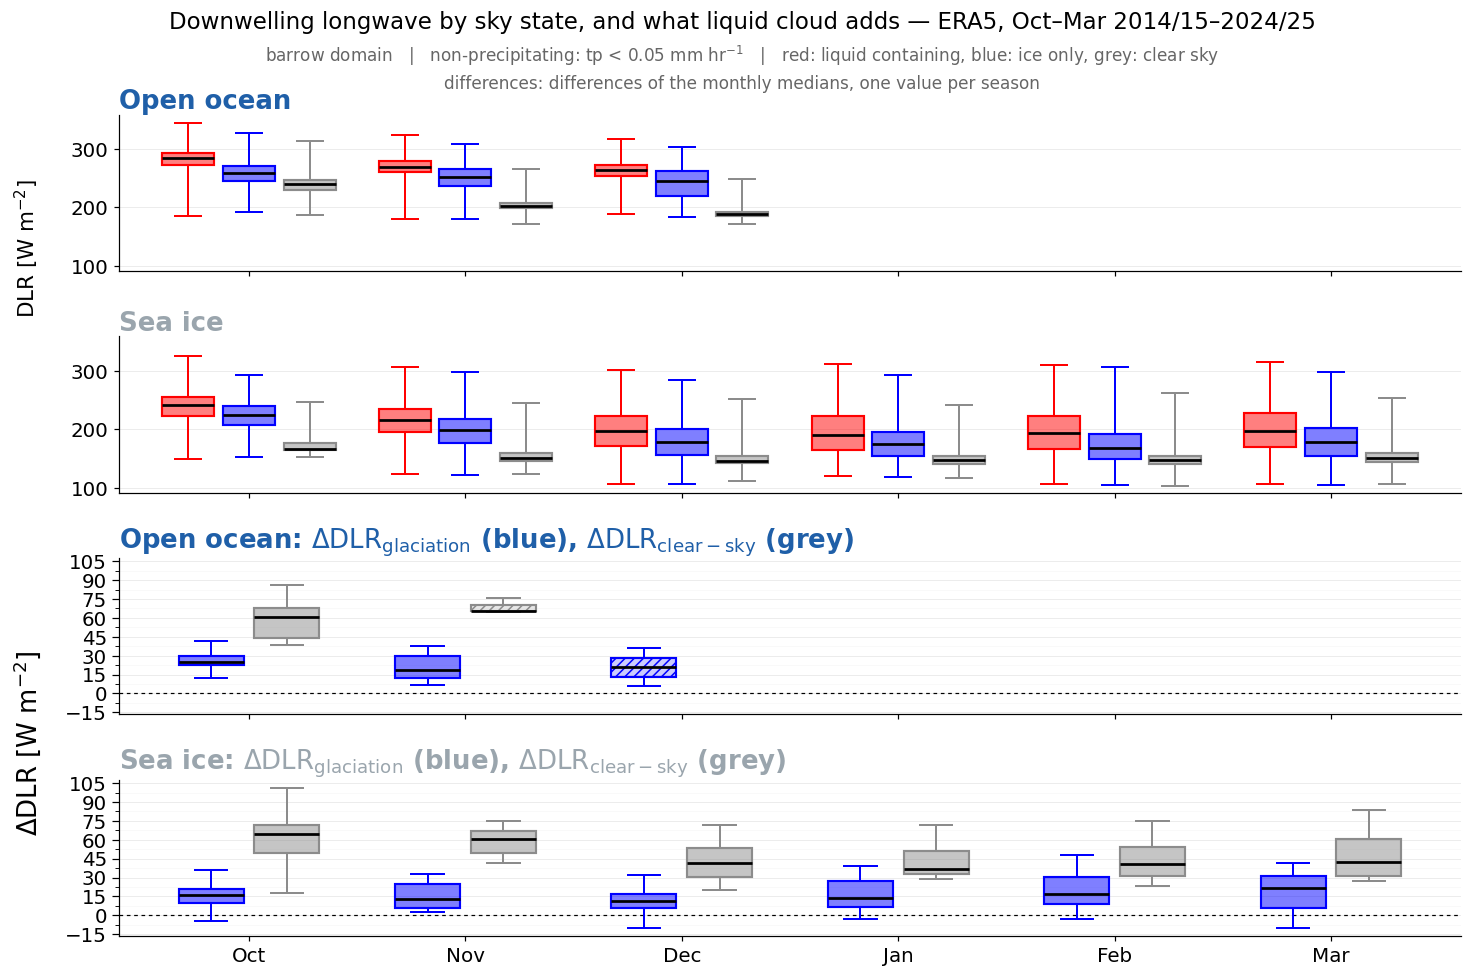

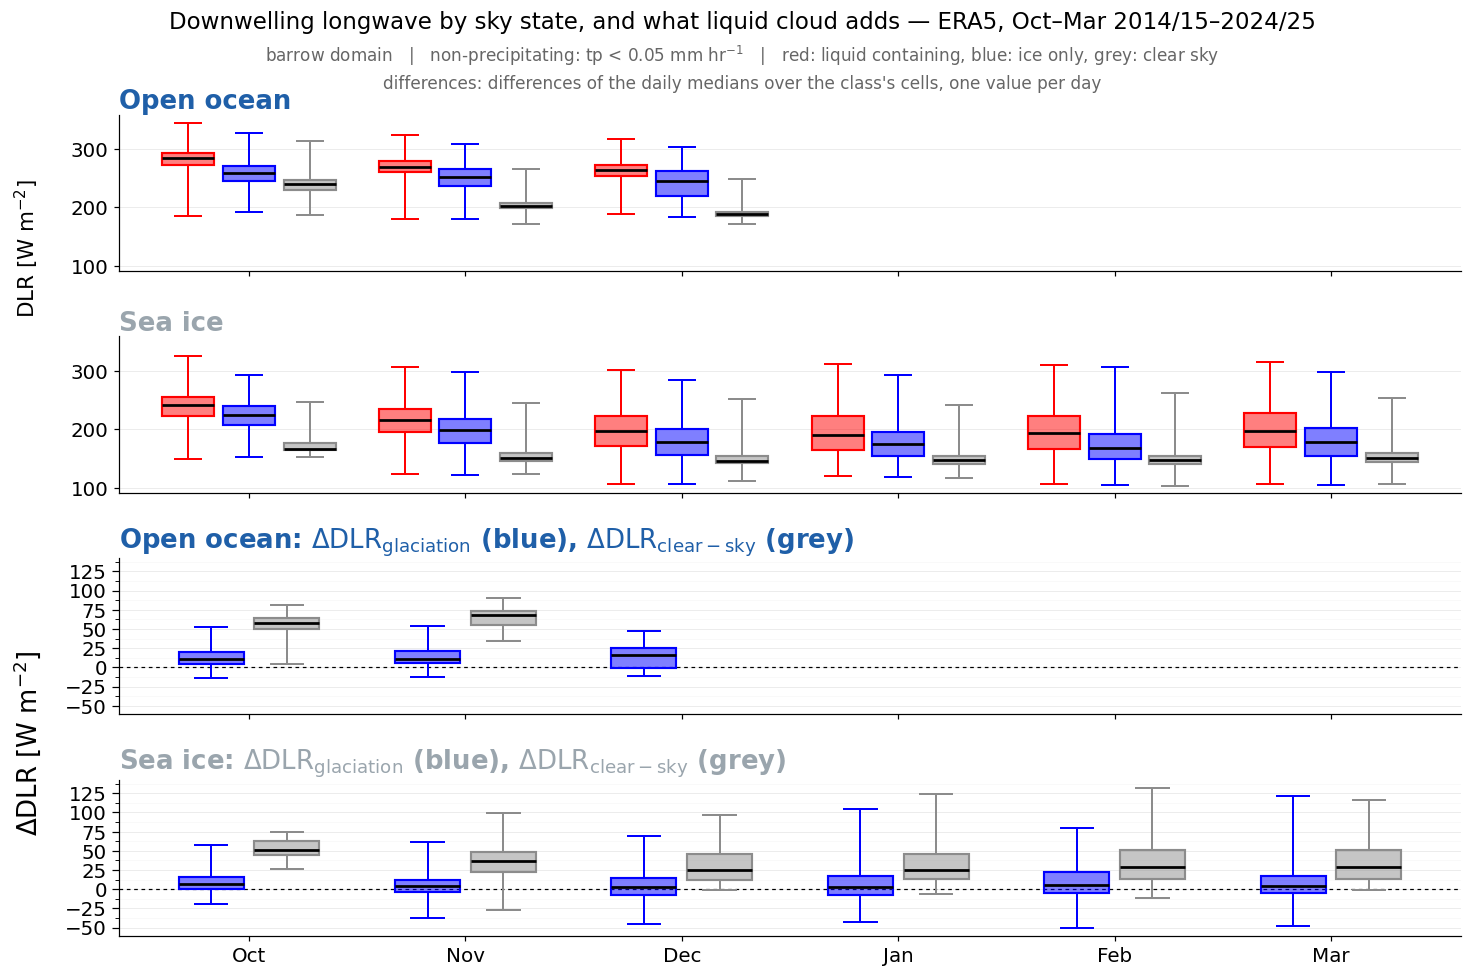

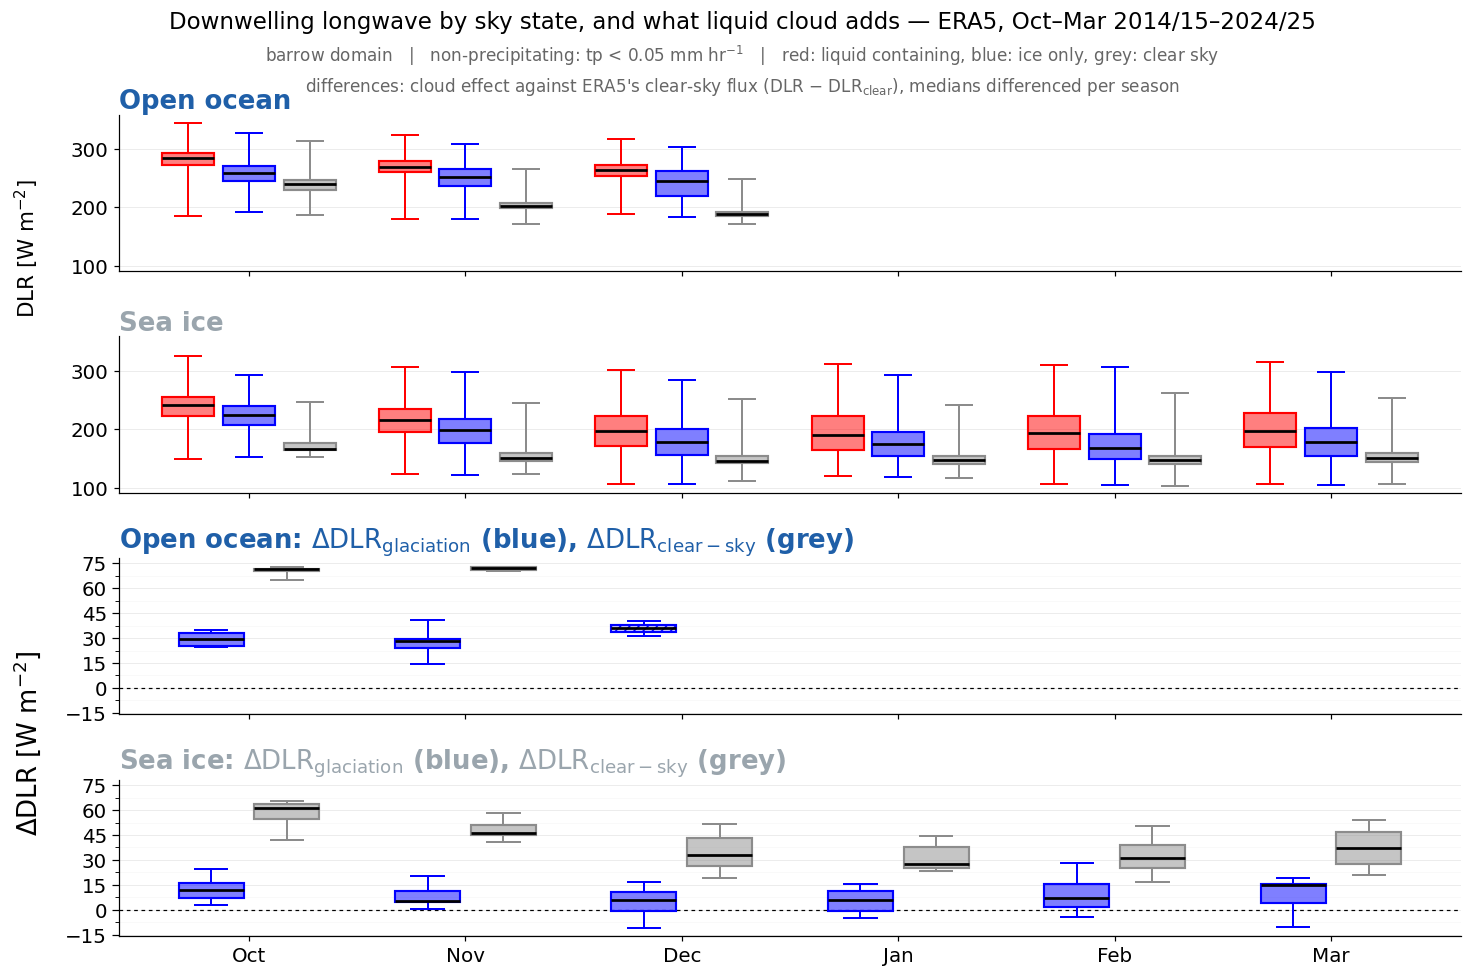

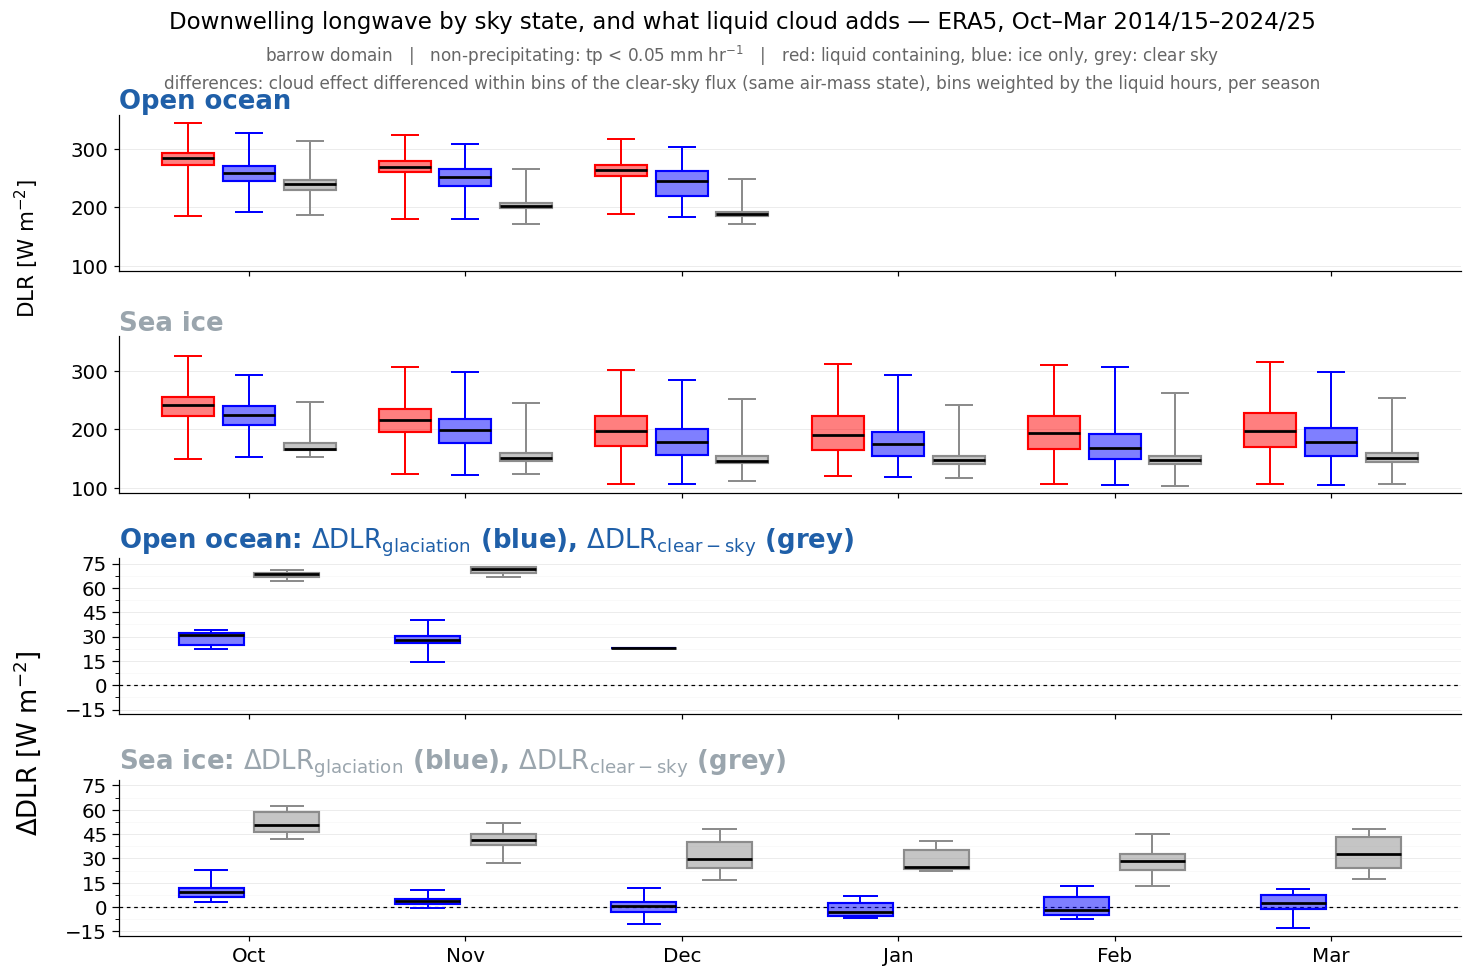

In [ ]:
# Is ERA5's clear-sky flux a fair per-hour reference? Median CRE by state:
# about zero under clear sky, the state's longwave forcing under cloud.
dlr.print_cre_check(A_precip, D_precip)

# The four methods side by side (median of each box's values), with the
# matched method's coverage. One block per surface: land, open ocean,
# marginal ice zone and pack ice -- two more than the figure below draws.
# Pass classes=(...) for a different set, "coastal" included.
methods_tbl = dlr.print_diff_methods_table(A_precip, D_precip)

# The figure for each method; each saves under its own suffix.
for method in dlr.DIFF_METHODS:
    dlr.fig_monthly_dlr_box_by_class_forOV_ver2(A_precip, D_precip, out_dir=SAVE_DIR,
                                                method=method)

#### The share of cold-season hours in each sky state, and the numbers behind the boxes

`partly*` is every valid hour in none of the three states; `no phase` the
overcast-but-condensate-free hours, listed separately because figures 1–2
fold them into ice only. Domain shares are cos(latitude)-weighted; the ARM
cell's are plain shares of hours.

Both tables also give, for every month, the **median downwelling longwave in
each state and the differences between states** — liquid − ice, liquid −
clear, ice − clear, in W m⁻². The share table has them domain beside ARM cell
(from the 1 W m⁻² histograms, so exact to a bin); the domain statistics table
has them as the last three columns of each row, as 7a's table does for the
ARM cell. Both return them under `"diff_median"`.

**Read the `all` row with care.** Its medians are pooled over every hour of
the window, but its differences are the hour-weighted **mean of the monthly
differences**, not the difference of the pooled medians. The two are not
close: the sky states have different seasonal make-up — 48% of
liquid-containing cell-hours fall in October–November against 12% of
ice-only ones and 8% of clear ones — so pooled liquid is an autumn number
and pooled ice a winter one, and their difference (+44 W m⁻² domain-wide)
mostly measures autumn against winter. Differencing within each month holds
the season, and with it the temperature and humidity background, fixed;
that is the phase effect (+19 to +26 W m⁻² for liquid − ice).

In [ ]:
frac_tbl = dlr.print_state_fraction_table(A_precip, D_precip)
dom_tbl = dlr.print_monthly_dlr_table_domain(A_precip, D_precip)


  Share of cold-season hours in each sky state, ERA5 -- non-precipitating hours (tp < 0.05 mm/hr)
  11 seasons 2014/15–2024/25   |   domain: 2,501 cells, cos-latitude weighted cell-hours   |   clear sky: tcc < 0.05, LWP <= 0.01 and IWP <= 0.01 g m-2

                           --- barrow domain ---                                     --- ARM cell ---                  
    month    liq cont ice only    clear  partly* no phase  hours    liq cont ice only    clear  partly* no phase  hours
    Oct         65.0%     5.9%     0.7%    28.4%     0.0% 16.14M       49.9%     7.4%     0.9%    41.8%     0.0%  6,524
    Nov         60.2%    15.9%     1.0%    22.9%     0.0% 17.03M       56.8%    11.9%     0.2%    31.1%     0.0%  6,521
    Dec         37.3%    30.9%     3.0%    28.9%     0.1% 18.95M       38.2%    22.8%     0.6%    38.4%     0.0%  7,463
    Jan         27.5%    38.8%     3.9%    29.8%     0.1% 18.95M       33.5%    28.6%     2.1%    35.8%     0.0%  7,601
    Feb         27.5%    39.

### 7c. The distribution of the flux — ARM cell against the whole domain

All hours of the eleven seasons, no precipitation filter (the shape of the
distribution is a property of the whole atmosphere, and the filter removes
cloudy hours preferentially; `precip_filter=True` draws the filtered
population instead). Both curves are 2 W m⁻² histograms normalised to unit
area, so they are comparable across 48,120 hours at the cell and 120 million
cell-hours over the domain.

**Why this figure.** Arctic winter downwelling longwave at the surface is
bimodal in observations — a radiatively clear state and an opaque-cloud
state, with little time spent between them (Stramler, Del Genio and Rossow
2011, *J. Climate*, from SHEBA; the same two states at N-ICE2015 in Graham et
al. 2017, *J. Climate*) — and reanalyses have been found to under-populate the
clear state over Arctic sea ice (Graham et al. 2019, *JGR Atmospheres*, six
reanalyses including ERA5). *Check these three against the papers before
quoting them on a slide; the characterisations are from memory.*

**What ERA5 shows here.** Domain-wide (black), a sharp low mode at
~150 W m⁻² and a broad cloudy plateau over 185–250 W m⁻², with **no trough
between them**. At the ARM cell (dashed), the low mode is only a shoulder and
the distribution is essentially one broad hump over 170–280 W m⁻². The
second copy, `show_states=True`, splits the domain curve by sky state, each
scaled by its share of hours so the pieces sum to the black curve: the low
mode is filled by hours ERA5 labels **partly cloudy** (dotted grey, peak at
150 W m⁻²) and **ice only** (blue, peak at 150 W m⁻²), while the `tcc < 0.05`
clear state (grey, 2.7% of hours) is a small contribution beneath it. So ERA5
does produce a radiatively clear mode over the region — it just does not
call those hours clear, and at the ARM cell it barely produces it at all.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_dlr_pdf_site_vs_domain_allhours_mean2014-2024.png
  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_dlr_pdf_site_vs_domain_allhours_mean2014-2024 - by-state.png


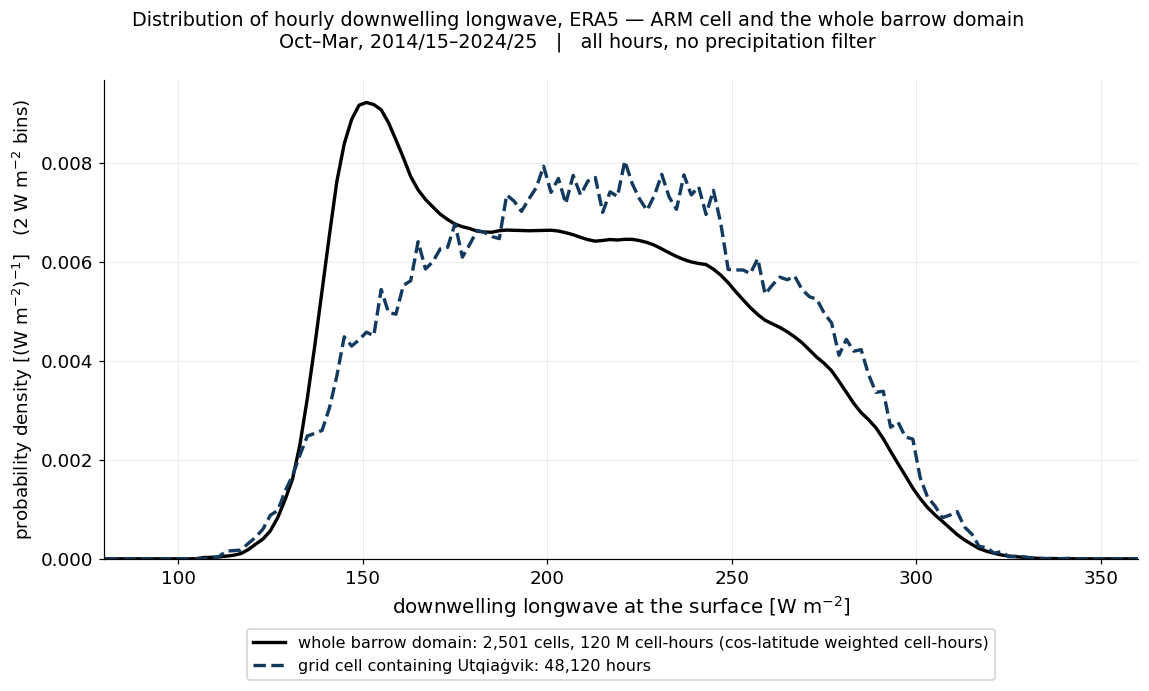

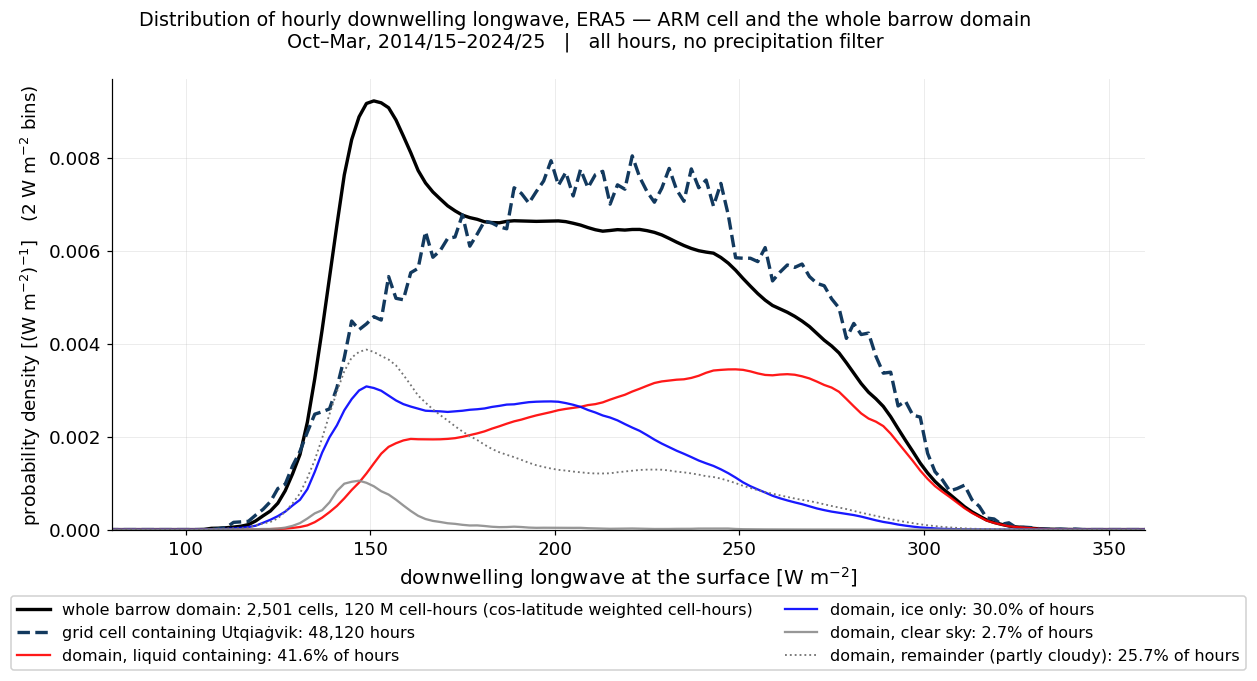

In [ ]:
dlr.fig_dlr_pdf(A_precip, D_precip, out_dir=SAVE_DIR);
dlr.fig_dlr_pdf(A_precip, D_precip, out_dir=SAVE_DIR, show_states=True);

## Figure 8 — Normalised surface-flux response to DLR + SW$_{net}$

The slide version of the monthly partition: land, open ocean and sea ice,
each with its own y axis, side by side (`layout="row"` fills the width of a
16:9 slide under its title). Within each (class, month) the four responders
— upwelling longwave, sensible heat, latent heat, and the residual into the
surface — are regressed on the net radiative forcing
$F = \mathrm{DLR} + \mathrm{SW}_{net}$, and each response $f_k$ is divided
by the sum of magnitudes across the terms,

$$
s_k = \frac{|f_k|}{\sum_j |f_j|} ,
$$

so every share lies in $[0, 1]$ and the shares sum to one: the fraction of
the *gross* flux change per W m⁻² of forcing that each channel carries.

**What this is not.** It is not a partition of the forcing. Where every
$f_k$ is non-negative the denominator is one and the shares *are* the
partition; where a channel turns into a source the denominator exceeds one
and every share shrinks. `signed=False` plots the magnitudes, so the figure
no longer shows which channels are sources — read it as activity only.
The sign convention (`convention`, default ERA5: positive is a change in
downward flux) is applied before normalising, and the palette follows the
module default (`palette="sledd"`); `palette="slide"` switches to the
clash-free `MONTHLY_STYLE_SIMPLE` colours.

Source: `turbulent_flux_response_to_DLR_and_SW.ipynb`, section 4a,
*normalised by the sum of magnitudes*.

**ver2 — markers scaled by r².** `fig_monthly_response_simple_normalized_ver2`
draws each marker with an area of `100 × r²`, so a month whose regression
explains none of the variance states its value without asserting it, and the
legend carries a size key at r² = 0.1, 0.5 and 1.0 (Sledd et al. Fig. 2a does
the same). The r² is of the underlying regression of that **term** on the
forcer — the quantity `fig_monthly_response` already sizes its markers by —
**not** of the normalised share, which is a ratio of fitted slopes and has no
residual of its own. It reads immediately over pack ice: upwelling longwave
and the residual sit at r² ≈ 0.5–0.85 and draw large, while the sensible and
latent terms fall to r² ≈ 0.01–0.17 and nearly vanish, which is the honest
picture of how well those two are constrained. `r2_size_max` and
`r2_legend_values` are the knobs.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_monthly_response_simple_norm_fnet_cloud_era5_sledd_abs_wide_mean2014-2025.png
  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_monthly_response_simple_norm_fnet_cloud_era5_sledd_abs_wide_r2size_mean2014-2025.png


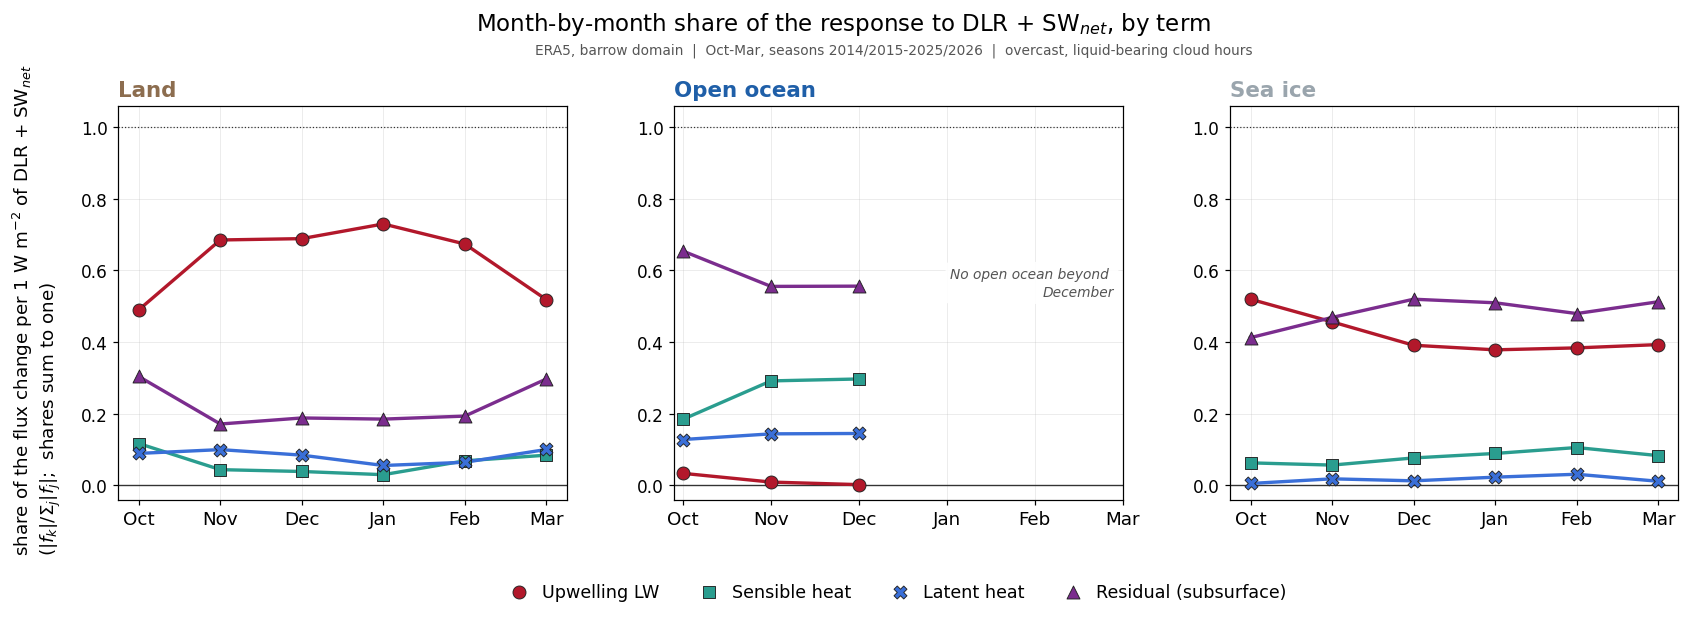

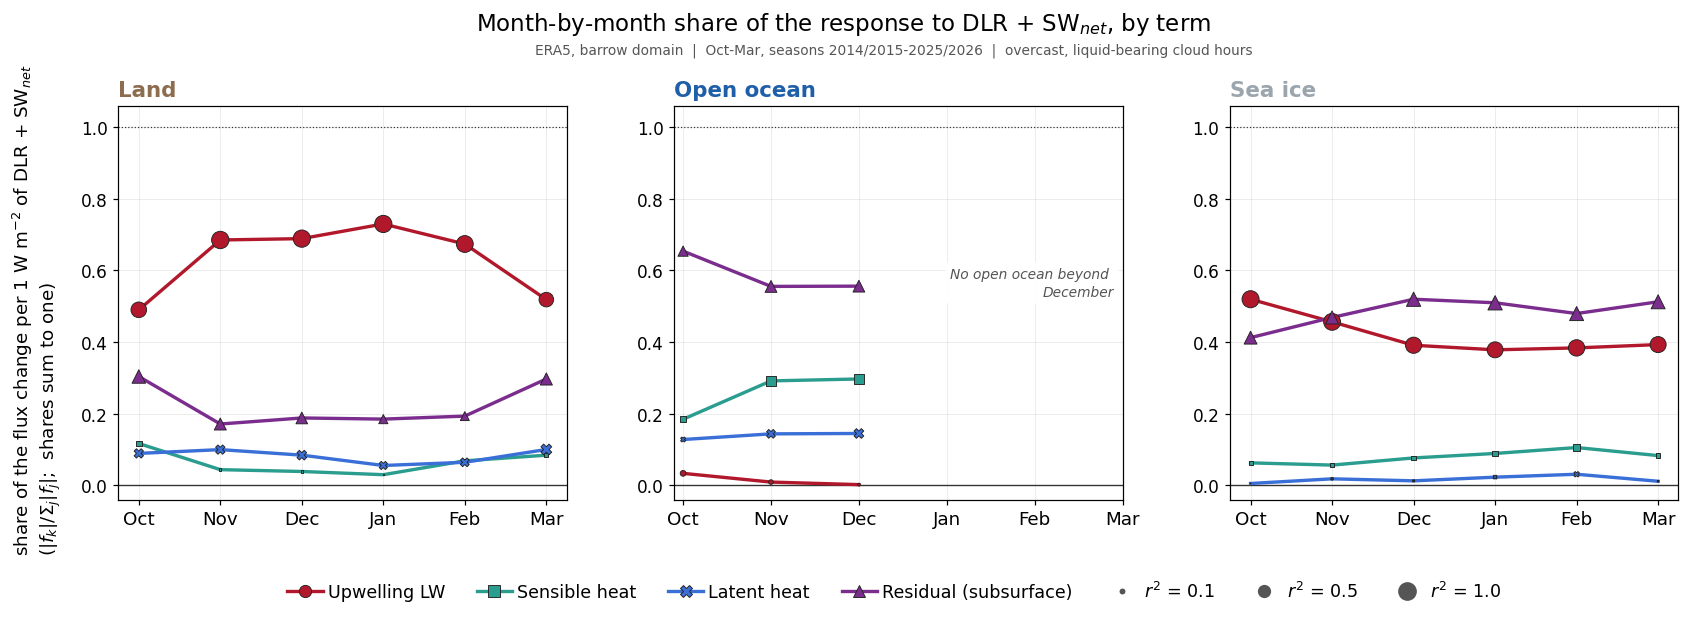

In [23]:
tfr.fig_monthly_response_simple_normalized(
    A_flux, forcer="fnet", layout="row", out_dir=SAVE_DIR, dpi=DPI, signed=False);

# ver2: the same figure with each marker's AREA scaled by the r^2 of the
# regression behind it (100 at r^2 = 1, nothing at r^2 = 0), and a size key
# in the legend at r^2 = 0.1, 0.5 and 1.0, as Sledd et al. Fig. 2a has.
# Saved with an _r2size tag, so it does not overwrite the figure above.
tfr.fig_monthly_response_simple_normalized_ver2(
    A_flux, forcer="fnet", layout="row", out_dir=SAVE_DIR, dpi=DPI, signed=False);


## Domain thumbnail

Where the Barrow domain is, for the corner of any domain-wide figure. A North
Polar Stereographic disc down to 66°N (about the Arctic Circle), turned so the domain sits at the
bottom, with the archive's own grid bounds (70–80°N, 165–150°W, read from
`A_precip.ds`) outlined in red — the parallels curve as they should on this
projection. `mark_site=True` adds the ARM site as a dot; `title=None` drops
the caption; `lat_min`, `central_longitude`, `box_color` and `size_in` are
the other knobs. Saved as `barrow_domain_thumbnail.png`, with no season tag
since it depends on none.

Source: `map_liquid_hours.fig_domain_thumbnail`, new for this talk.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_domain_thumbnail.png


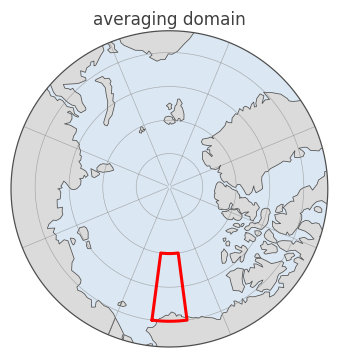

In [ ]:
mlh.fig_domain_thumbnail(A_precip, out_dir=SAVE_DIR, dpi=350);